<a href="https://colab.research.google.com/github/jamiroquai1225/Forecasting/blob/main/%EC%A0%9C%EC%A3%BC%EA%B3%B5%ED%95%AD_%EB%AC%BC%EB%8F%99%EB%9F%89_%EC%88%98%EC%A0%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# 파일 경로
file_path = r"C:\Users\vpsxl\Desktop\무역학회지 8월호\data.xlsx"

# 데이터 불러오기
df = pd.read_excel(file_path, sheet_name='데이터')

# 연도+월을 datetime으로 변환
df['Date'] = pd.to_datetime(df[['year', 'month']].assign(DAY=1))

# 컬럼 정리
df = df[['Date', 'airport', 'port']]

# 결과 확인
print(df.head())

# 인덱스 설정 (선택)
df.set_index('Date', inplace=True)

# 파일 저장
df.to_excel(r"C:\Users\vpsxl\Desktop\무역학회지 8월호\merged_data_final.xlsx")

print("✅ 전처리 완료! merged_data_final.xlsx로 저장했습니다.")


        Date  airport    port
0 2016-01-01    24517  915521
1 2016-02-01    24348  801001
2 2016-03-01    24561  944258
3 2016-04-01    23699  880046
4 2016-05-01    22830  900687
✅ 전처리 완료! merged_data_final.xlsx로 저장했습니다.


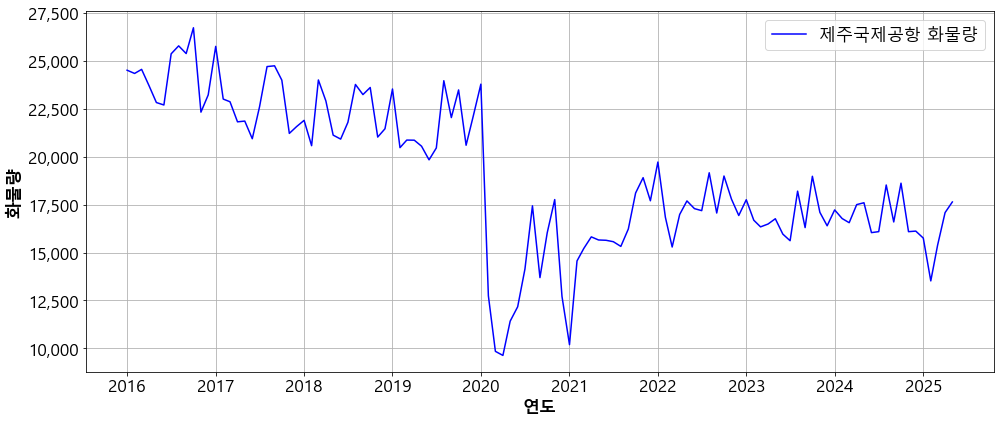

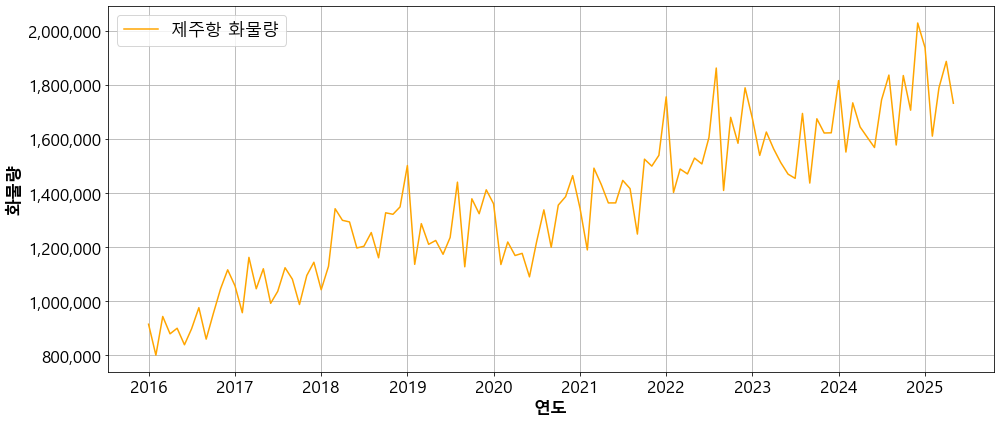

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import os

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
file_path = r"C:\Users\vpsxl\Desktop\무역학회지 8월호\data.xlsx"
data_df = pd.read_excel(file_path, sheet_name='데이터')
data_df['Date'] = pd.to_datetime(data_df[['year', 'month']].assign(DAY=1))
data_df.set_index('Date', inplace=True)

# 저장 폴더 설정
save_dir = r"C:\Users\vpsxl\Desktop\무역학회지 8월호"
os.makedirs(save_dir, exist_ok=True)

# 스타일 옵션
label_fontsize = 17
tick_fontsize = 17

# 제주공항 화물량 시계열
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(data_df['airport'], label='제주국제공항 화물량', color='blue')
ax.set_xlabel('연도', fontsize=label_fontsize, fontweight='bold')
ax.set_ylabel('화물량', fontsize=label_fontsize, fontweight='bold')

ax.legend(fontsize=label_fontsize)
ax.grid(True)

# 축 글씨 크기 조정
ax.tick_params(axis='x', labelsize=tick_fontsize)
ax.tick_params(axis='y', labelsize=tick_fontsize)

# y축 천단위 컴마
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format(int(x), ',')))

plt.tight_layout()
plt.savefig(os.path.join(save_dir, '제주공항_화물량_시계열.png'), dpi=300)
plt.show()

# 제주항 물동량 시계열
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(data_df['port'], label='제주항 화물량', color='orange')
ax.set_xlabel('연도', fontsize=label_fontsize, fontweight='bold')
ax.set_ylabel('화물량', fontsize=label_fontsize, fontweight='bold')
ax.legend(fontsize=label_fontsize)
ax.grid(True)

ax.tick_params(axis='x', labelsize=tick_fontsize)
ax.tick_params(axis='y', labelsize=tick_fontsize)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format(int(x), ',')))

plt.tight_layout()
plt.savefig(os.path.join(save_dir, '제주항_물동량_시계열.png'), dpi=300)
plt.show()


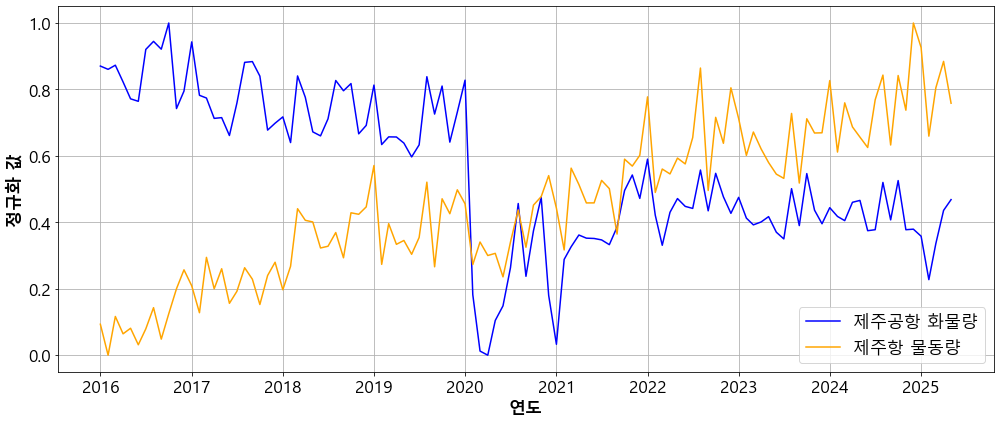

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
file_path = r"C:\Users\vpsxl\Desktop\무역학회지 8월호\data.xlsx"
data_df = pd.read_excel(file_path, sheet_name='데이터')

# Date 생성
data_df['Date'] = pd.to_datetime(data_df[['year', 'month']].assign(DAY=1))
data_df.set_index('Date', inplace=True)

# 정규화 (Min-Max Normalization)
data_df['제주공항_정규화'] = (data_df['airport'] - data_df['airport'].min()) / (data_df['airport'].max() - data_df['airport'].min())
data_df['제주항_정규화'] = (data_df['port'] - data_df['port'].min()) / (data_df['port'].max() - data_df['port'].min())

# 그래프 저장 경로 설정
save_dir = r"C:\Users\vpsxl\Desktop\무역학회지 8월호"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, '제주공항_vs_제주항_정규화_비교.png')

# 시계열 비교 그래프
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(data_df['제주공항_정규화'], label='제주공항 화물량', color='blue')
ax.plot(data_df['제주항_정규화'], label='제주항 물동량', color='orange')

# 폰트 크기 17 적용
fontsize_all = 17
ax.set_xlabel('연도', fontsize=fontsize_all, fontweight='bold')
ax.set_ylabel('정규화 값', fontsize=fontsize_all, fontweight='bold')
ax.legend(fontsize=fontsize_all)
ax.grid(True)
ax.tick_params(axis='x', labelsize=fontsize_all)
ax.tick_params(axis='y', labelsize=fontsize_all)

plt.tight_layout()
plt.savefig(save_path, dpi=300)
plt.show()


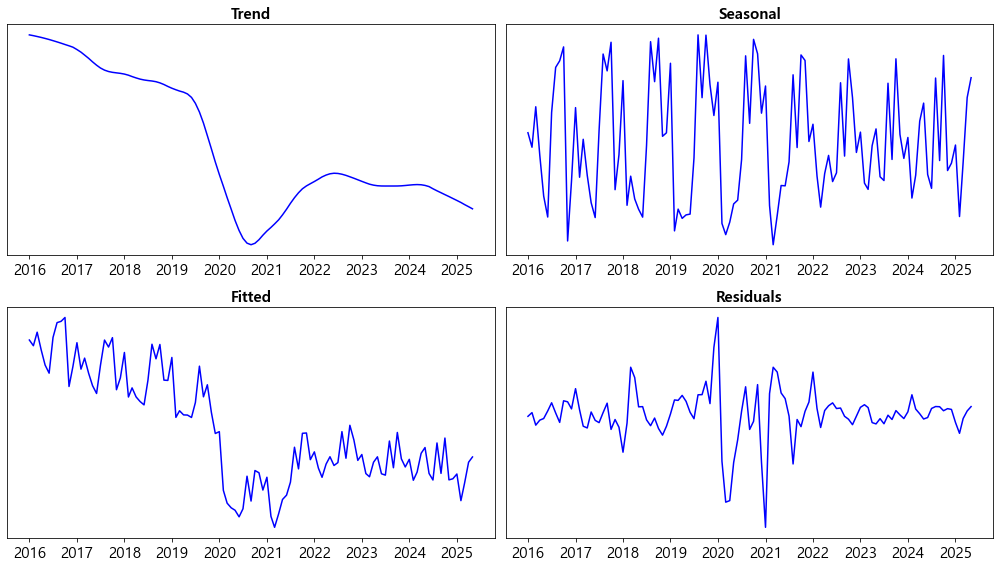

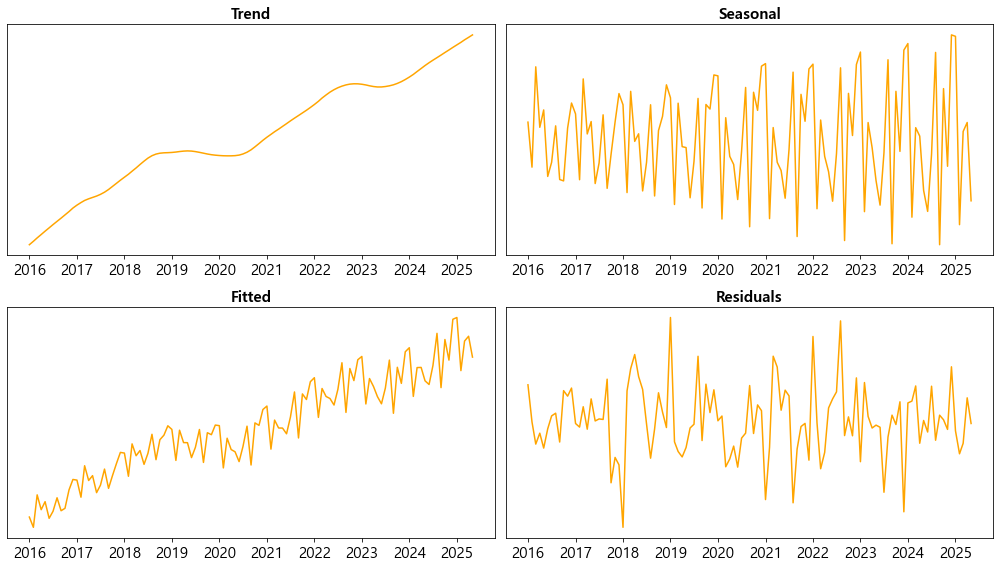

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
file_path = r"C:\Users\vpsxl\Desktop\무역학회지 8월호\data.xlsx"
df = pd.read_excel(file_path, sheet_name='데이터')
df['Date'] = pd.to_datetime(df[['year', 'month']].assign(DAY=1))
df.set_index('Date', inplace=True)

# 폰트 크기
fontsize_all = 15

# 제주공항 STL 분해
stl_airport = STL(df['airport'], period=12).fit()
trend_airport = stl_airport.trend
seasonal_airport = stl_airport.seasonal
resid_airport = stl_airport.resid
fitted_airport = trend_airport + seasonal_airport

# 제주항 STL 분해
stl_port = STL(df['port'], period=12).fit()
trend_port = stl_port.trend
seasonal_port = stl_port.seasonal
resid_port = stl_port.resid
fitted_port = trend_port + seasonal_port

# 제주공항 4분할 그림
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

components_airport = [trend_airport, seasonal_airport, fitted_airport, resid_airport]
titles = ['Trend', 'Seasonal', 'Fitted', 'Residuals']

for ax, comp, title in zip(axes.flat, components_airport, titles):
    ax.plot(comp, color='blue')
    ax.set_title(title, fontsize=fontsize_all, fontweight='bold')  # 제목 bold 처리
    ax.tick_params(axis='x', labelsize=fontsize_all)
    ax.tick_params(axis='y', labelleft=False, length=0)
    ax.yaxis.set_ticks([])

plt.tight_layout()
plt.savefig(r"C:\Users\vpsxl\Desktop\무역학회지 8월호\제주공항_분해.png", dpi=300)
plt.show()

# 제주항 4분할 그림
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

components_port = [trend_port, seasonal_port, fitted_port, resid_port]
colors = ['orange', 'orange', 'orange', 'orange']

for ax, comp, title, color in zip(axes.flat, components_port, titles, colors):
    ax.plot(comp, color=color)
    ax.set_title(title, fontsize=fontsize_all, fontweight='bold')  # 제목 bold 처리
    ax.tick_params(axis='x', labelsize=fontsize_all)
    ax.tick_params(axis='y', labelleft=False, length=0)
    ax.yaxis.set_ticks([])

plt.tight_layout()
plt.savefig(r"C:\Users\vpsxl\Desktop\무역학회지 8월호\제주항_분해.png", dpi=300)
plt.show()


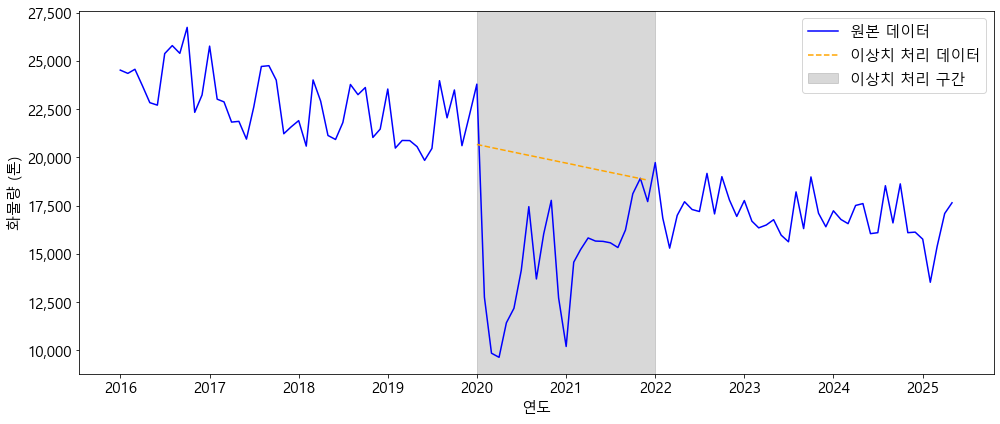

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.linear_model import LinearRegression
import os

# 1. 윈도우 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기
file_path = r"C:\Users\vpsxl\Desktop\무역학회지 8월호\data.xlsx"
df = pd.read_excel(file_path, sheet_name="데이터")
df["Date"] = pd.to_datetime(df[["year", "month"]].assign(DAY=1))
df.set_index("Date", inplace=True)

# 3. 제주공항 화물량 시계열 선택 및 복사
y = df["airport"].astype(float).copy()

# 4. 이상치 처리 기간 설정: 2020년 1월 ~ 2021년 12월
outlier_period = (y.index >= "2020-01-01") & (y.index <= "2021-12-31")

# 5. 이상치 구간 제외한 데이터로 선형회귀 모델 적합
X = np.arange(len(y)).reshape(-1, 1)
X_no_outlier = X[~outlier_period]
y_no_outlier = y[~outlier_period]

model = LinearRegression()
model.fit(X_no_outlier, y_no_outlier)

# 6. 이상치 구간에 대한 예측값 생성
y_pred_outlier = model.predict(X[outlier_period])

# 7. 원본 데이터에서 이상치 구간만 예측값으로 대체
y_corrected = y.copy()
y_corrected[outlier_period] = y_pred_outlier

# 8. 저장 경로 설정
save_dir = r"C:\Users\vpsxl\Desktop\무역학회지 8월호"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "제주공항_이상치처리_비교.png")

# 9. 시각화
fig, ax = plt.subplots(figsize=(14,6))

# 전체 원본 데이터 시각화
ax.plot(y, label="원본 데이터", color='blue')

# 이상치 처리 구간만 점선으로 시각화
corrected_dates = y[outlier_period].index
ax.plot(corrected_dates, y_corrected[outlier_period], label="이상치 처리 데이터", linestyle="--", color='orange')

# 이상치 처리 구간 회색 음영으로 강조
ax.axvspan("2020-01-01", "2021-12-31", color="gray", alpha=0.3, label="이상치 처리 구간")

# 제목, 축, 범례 등 폰트 크기 설정
fontsize_all = 15
ax.set_xlabel("연도", fontsize=fontsize_all)
ax.set_ylabel("화물량 (톤)", fontsize=fontsize_all)
ax.legend(fontsize=fontsize_all)
ax.tick_params(axis='x', labelsize=fontsize_all)
ax.tick_params(axis='y', labelsize=fontsize_all)

# y축 천단위 컴마 표시
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format(int(x), ',')))

# 10. 저장 및 출력
plt.tight_layout()
plt.savefig(save_path, dpi=300)
plt.show()


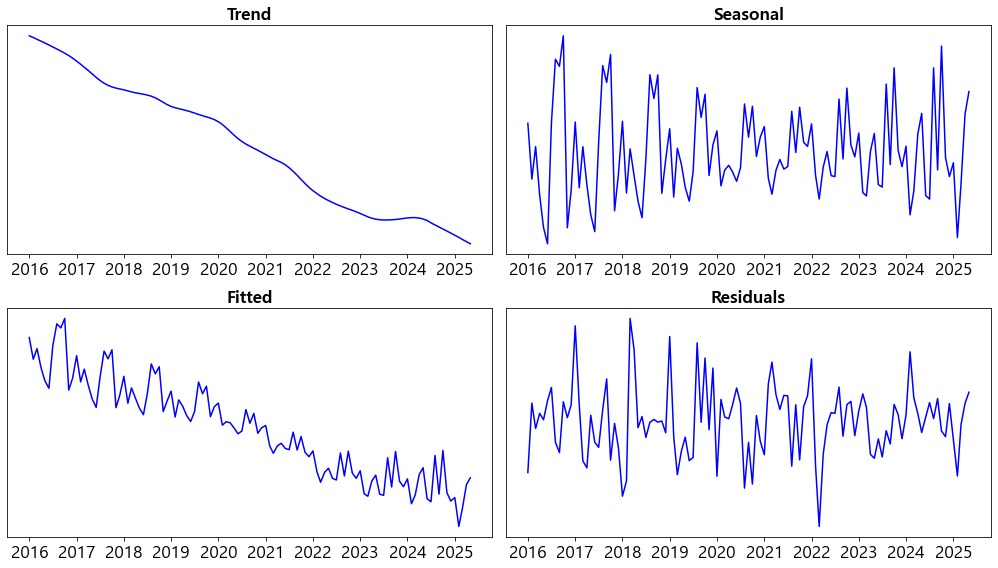

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.seasonal import STL
import os

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 불러오기
file_path = r"C:\Users\vpsxl\Desktop\무역학회지 8월호\data.xlsx"
df = pd.read_excel(file_path, sheet_name="데이터")
df["Date"] = pd.to_datetime(df[["year", "month"]].assign(DAY=1))
df.set_index("Date", inplace=True)

# 2. 제주공항 화물량 시계열 이상치 처리
y = df["airport"].astype(float).copy()
outlier_period = (y.index >= "2020-01-01") & (y.index <= "2021-12-31")

X = np.arange(len(y)).reshape(-1, 1)
X_no_outlier = X[~outlier_period]
y_no_outlier = y[~outlier_period]

model = LinearRegression()
model.fit(X_no_outlier, y_no_outlier)
y_pred_outlier = model.predict(X[outlier_period])

y_corrected = y.copy()
y_corrected[outlier_period] = y_pred_outlier

# 3. STL 분해 수행
stl = STL(y_corrected, period=12)
result = stl.fit()
trend = result.trend
seasonal = result.seasonal
resid = result.resid
fitted = trend + seasonal

# 4. 시각화: 4분할 그래프
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

components = [trend, seasonal, fitted, resid]
titles = ['Trend', 'Seasonal', 'Fitted', 'Residuals']
colors = ['blue', 'blue', 'blue', 'blue']

fontsize_all = 17

for ax, comp, title, color in zip(axes.flat, components, titles, colors):
    ax.plot(comp, color=color)
    ax.set_title(title, fontsize=fontsize_all, fontweight='bold')
    ax.tick_params(axis='x', labelsize=fontsize_all)
    ax.tick_params(axis='y', labelleft=False, length=0)
    ax.yaxis.set_ticks([])

plt.tight_layout()

# 5. 저장
save_path = r"C:\Users\vpsxl\Desktop\무역학회지 8월호\제주공항_이상치처리_STL분해.png"
plt.savefig(save_path, dpi=300)
plt.show()


# test


[공항·항만 ADF 결과]
              시계열  ADF Statistic  p-value  Lags Used  N Obs   Crit 1%   Crit 5%  Crit 10%      IC Best
    제주공항(보정 전) 원시      -1.729720 0.415869          8    104 -3.494850 -2.889758 -2.581822 1,783.190155
    제주공항(보정 후) 원시      -1.705559 0.428251         12    100 -3.497501 -2.890906 -2.582435 1,656.720476
 제주공항(보정 후) 1차 차분      -5.573255 0.000001         11    100 -3.497501 -2.890906 -2.582435 1,640.582494
           제주항 원시      -0.597635 0.871516         11    101 -3.496818 -2.890611 -2.582277 2,583.266720
        제주항 1차 차분      -5.939555 0.000000         10    101 -3.496818 -2.890611 -2.582277 2,556.047379

CSV 저장: C:\Users\vpsxl\Desktop\무역학회지 8월호\ADF_공항보정_항만_결과표.csv


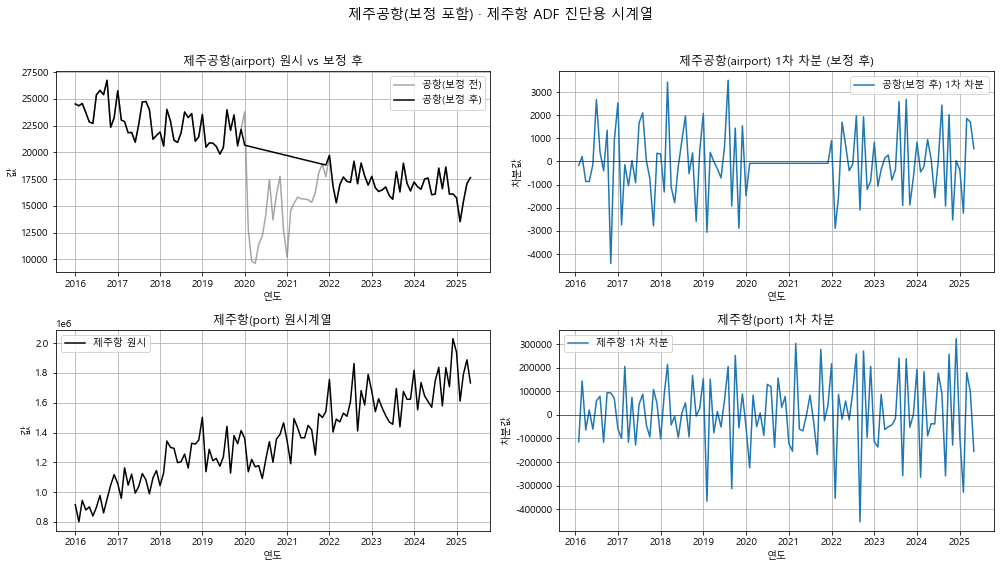

       제주공항(보정 전) 원시 | p-value=0.415869 → 비정상 (H0 채택)
       제주공항(보정 후) 원시 | p-value=0.428251 → 비정상 (H0 채택)
    제주공항(보정 후) 1차 차분 | p-value=0.000001 → 정상성 (H0 기각)
              제주항 원시 | p-value=0.871516 → 비정상 (H0 채택)
           제주항 1차 차분 | p-value=0.000000 → 정상성 (H0 기각)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import adfuller

# ---------------------------
# 한글 폰트
# ---------------------------
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# ---------------------------
# 경로/데이터 불러오기
# ---------------------------
file_path = r"C:\Users\vpsxl\Desktop\무역학회지 8월호\data.xlsx"
save_dir  = r"C:\Users\vpsxl\Desktop\무역학회지 8월호"

df = pd.read_excel(file_path, sheet_name="데이터")
df["Date"] = pd.to_datetime(df[["year", "month"]].assign(DAY=1))
df.set_index("Date", inplace=True)

# ---------------------------
# 제주공항 이상치 보정 (2020-01 ~ 2021-12 구간 선형회귀로 대체)
# ---------------------------
y_air_raw = df["airport"].astype(float).copy()
outlier_period = (y_air_raw.index >= "2020-01-01") & (y_air_raw.index <= "2021-12-31")

# 시간 인덱스를 숫자로 변환하여 추세 회귀
X = np.arange(len(y_air_raw)).reshape(-1, 1)
X_no = X[~outlier_period]
y_no = y_air_raw[~outlier_period].values

lr = LinearRegression()
lr.fit(X_no, y_no)

y_air_corr = y_air_raw.copy()
y_air_corr[outlier_period] = lr.predict(X[outlier_period]).ravel()

# 제주항 원시 시계열
y_port_raw = df["port"].astype(float).copy()

# ---------------------------
# ADF 함수
# ---------------------------
def run_adf(series: pd.Series, name: str):
    s = series.dropna()
    adf_stat, pval, usedlag, nobs, critvals, icbest = adfuller(s)
    return {
        "시계열": name,
        "ADF Statistic": adf_stat,
        "p-value": pval,
        "Lags Used": usedlag,
        "N Obs": nobs,
        "Crit 1%": critvals.get("1%"),
        "Crit 5%": critvals.get("5%"),
        "Crit 10%": critvals.get("10%"),
        "IC Best": icbest
    }

# ---------------------------
# 1) 공항·항만 동시 ADF (원시/1차 차분)
#    - 공항: 보정 전 / 보정 후 / 보정 후 1차 차분
#    - 항만: 원시 / 1차 차분
# ---------------------------
rows = []
rows.append(run_adf(y_air_raw,  "제주공항(보정 전) 원시"))
rows.append(run_adf(y_air_corr, "제주공항(보정 후) 원시"))
rows.append(run_adf(y_air_corr.diff(), "제주공항(보정 후) 1차 차분"))
rows.append(run_adf(y_port_raw, "제주항 원시"))
rows.append(run_adf(y_port_raw.diff(), "제주항 1차 차분"))

adf_df = pd.DataFrame(rows)[[
    "시계열","ADF Statistic","p-value","Lags Used","N Obs","Crit 1%","Crit 5%","Crit 10%","IC Best"
]]

pd.set_option('display.float_format', lambda x: f"{x:,.6f}")
print("\n[공항·항만 ADF 결과]")
print(adf_df.to_string(index=False))

csv_path = fr"{save_dir}\ADF_공항보정_항만_결과표.csv"
adf_df.to_csv(csv_path, index=False, encoding="utf-8-sig")
print(f"\nCSV 저장: {csv_path}")

# ---------------------------
# 2) 시각화 저장
#    (A) 공항 원시 vs 보정 후
#    (B) 공항 보정 후 1차 차분
#    (C) 항만 원시
#    (D) 항만 1차 차분
# ---------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
(ax1, ax2), (ax3, ax4) = axes

# (A) 공항 원시 vs 보정 후
ax1.plot(y_air_raw.index,  y_air_raw,  label="공항(보정 전)", color="gray", alpha=0.7)
ax1.plot(y_air_corr.index, y_air_corr, label="공항(보정 후)", color="black")
ax1.set_title("제주공항(airport) 원시 vs 보정 후")
ax1.set_xlabel("연도"); ax1.set_ylabel("값"); ax1.grid(True); ax1.legend()

# (B) 공항 보정 후 1차 차분
ax2.plot(y_air_corr.diff().index, y_air_corr.diff(), color="tab:blue", label="공항(보정 후) 1차 차분")
ax2.axhline(0, color="black", linewidth=0.8, alpha=0.6)
ax2.set_title("제주공항(airport) 1차 차분 (보정 후)")
ax2.set_xlabel("연도"); ax2.set_ylabel("차분값"); ax2.grid(True); ax2.legend()

# (C) 항만 원시
ax3.plot(y_port_raw.index, y_port_raw, color="black", label="제주항 원시")
ax3.set_title("제주항(port) 원시계열")
ax3.set_xlabel("연도"); ax3.set_ylabel("값"); ax3.grid(True); ax3.legend()

# (D) 항만 1차 차분
ax4.plot(y_port_raw.diff().index, y_port_raw.diff(), color="tab:blue", label="제주항 1차 차분")
ax4.axhline(0, color="black", linewidth=0.8, alpha=0.6)
ax4.set_title("제주항(port) 1차 차분")
ax4.set_xlabel("연도"); ax4.set_ylabel("차분값"); ax4.grid(True); ax4.legend()

plt.suptitle("제주공항(보정 포함) · 제주항 ADF 진단용 시계열", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.96])

img_path = fr"{save_dir}\ADF_공항보정_항만_시각화.png"
plt.savefig(img_path, dpi=300)
plt.show()

# ---------------------------
# 3) 간단 해석 힌트
# ---------------------------
def hint(row_name):
    p = adf_df.loc[adf_df["시계열"]==row_name, "p-value"].iloc[0]
    tag = "정상성 (H0 기각)" if p < 0.05 else "비정상 (H0 채택)"
    return p, tag

for name in ["제주공항(보정 전) 원시","제주공항(보정 후) 원시","제주공항(보정 후) 1차 차분",
             "제주항 원시","제주항 1차 차분"]:
    p, tag = hint(name)
    print(f"{name:>20s} | p-value={p:.6f} → {tag}")



=== SARIMA(무) Top-5 ===
     order       seasonal        aic        bic
 (1, 0, 1)  (0, 1, 2, 12)  10.000000  19.659128
 (2, 0, 1)  (0, 1, 2, 12)  12.000000  23.590954
 (2, 0, 3)  (0, 1, 2, 12)  16.000000  31.134562
 (3, 0, 3)  (0, 1, 2, 12)  18.000000  35.026383
 (3, 0, 1)  (0, 1, 2, 12) 172.353271 185.876051
Best AIC=10.00 | cfg=((1, 0, 1), (0, 1, 2, 12))


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



=== SARIMAX(외생) Top-5 ===
     order       seasonal        aic        bic
 (3, 0, 2)  (0, 1, 2, 12)  18.000000  35.208207
 (0, 0, 3)  (1, 1, 2, 12) 825.766675 840.901237
 (2, 0, 3)  (1, 1, 2, 12) 826.464346 845.382549
 (1, 0, 3)  (1, 1, 2, 12) 827.626023 844.652405
 (0, 0, 3)  (2, 1, 2, 12) 827.719997 844.746380
Best AIC=18.00 | cfg=((3, 0, 2), (0, 1, 2, 12))

=== SARIMA(외생 미포함, 차분→복원) ===
MAPE=9431891976281889388050167136587744886715907165861171797125820983584530080172566354718717055714520803770892288.0000, RMSE=746613414770816377381631483892441946089608582412060806914642752546476486946224038166730884553916489658845355835392.00

=== SARIMAX(외생 포함, 차분→복원) ===
MAPE=2627558869931536987395582198808576.0000, RMSE=132734821908463857879313682720289193984.00

[SARIMA(무)] 계수 / t / p
                               coef    t        p
ar.L1                     15.660535 -inf 0.000000
ma.L1                     -4.365314  inf 0.000000
ma.S.L12 -73,347,912,646,249.468750  inf 0.000000
ma.S.L24 284,

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



=== Prophet(무) ===
MAPE=0.0770, RMSE=1694.80
※ Prophet은 계수의 t/p를 제공하지 않습니다.

=== Prophet(외생) ===
MAPE=0.0801, RMSE=1743.85
※ Prophet은 계수의 t/p를 제공하지 않습니다.

[과적합 점검: In-sample vs Test RMSE]
SARIMA(무): In=125520060967898542752150696331616391472448672815942712799011433398986855144705235091456.00  | OOS=746613414770816377381631483892441946089608582412060806914642752546476486946224038166730884553916489658845355835392.00
SARIMAX(외생): In=459446508016319488311926194176.00 | OOS=132734821908463857879313682720289193984.00
Prophet(무): In=776.17  | OOS=1694.80
Prophet(외생): In=765.93 | OOS=1743.85


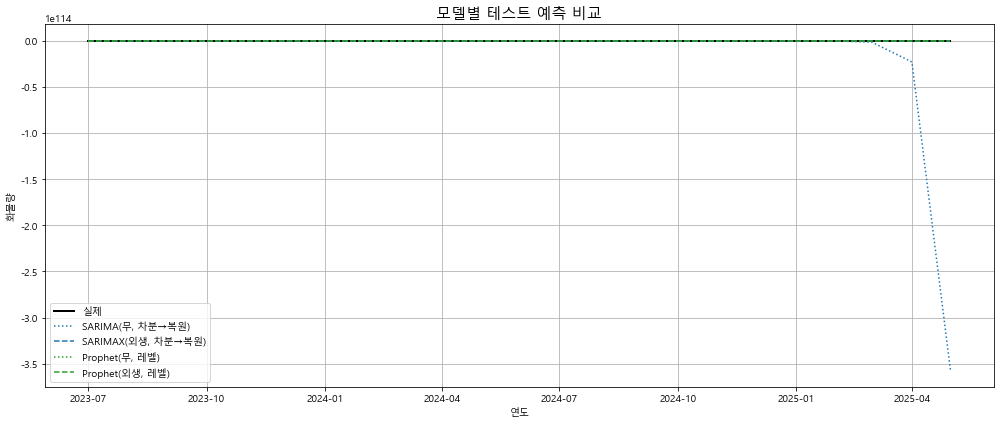


[Sanity]
외부차분==직접차분?: True
타입: float64 float64 float64
예측(diff) 앞: [-1.73249004e+88 -2.71317205e+89 -4.24897254e+90] [ 1.26983133e+31 -2.87626876e+31  6.51497708e+31]
예측(복원) 앞: [-1.73249004e+88 -2.88642106e+89 -4.53761465e+90] [ 1.26983133e+31 -1.60643744e+31  4.90853965e+31]
Prophet idx 일치?: True True


In [ ]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from prophet import Prophet

warnings.filterwarnings("ignore")

# =========================
# 0) 한글 폰트
# =========================
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# =========================
# 1) 경로/데이터 로드 + 이상치 보정
# =========================
file_path = r"C:\Users\vpsxl\Desktop\무역학회지 8월호\data.xlsx"
save_dir  = r"C:\Users\vpsxl\Desktop\무역학회지 8월호"

df = pd.read_excel(file_path, sheet_name="데이터")
df["Date"] = pd.to_datetime(df[["year","month"]].assign(DAY=1))
df.set_index("Date", inplace=True)

# y(제주공항) 이상치 보정: 2020-01~2021-12 구간을 선형추세로 대체
y_air = df["airport"].astype(float).copy()
mask_out = (y_air.index >= "2020-01-01") & (y_air.index <= "2021-12-31")
X = np.arange(len(y_air)).reshape(-1,1)
lr = LinearRegression().fit(X[~mask_out], y_air[~mask_out])
y_air_corr = y_air.copy()
y_air_corr[mask_out] = lr.predict(X[mask_out]).ravel()

# 외생변수(제주항)
x_port = df["port"].astype(float).copy()

# =========================
# 2) 학습/테스트 분할 (80/20) — 레벨 스케일
# =========================
split_idx = int(len(y_air_corr) * 0.8)
y_train_level = y_air_corr.iloc[:split_idx]
y_test_level  = y_air_corr.iloc[split_idx:]
x_train_level = x_port.iloc[:split_idx]
x_test_level  = x_port.iloc[split_idx:]

H = len(y_test_level)                         # 테스트 길이
last_train_level = float(y_train_level.iloc[-1])  # 복원 기준값(스칼라)

# =========================
# 3) 외부 1차 차분 (y, exog) + 분할
# =========================
y_diff = y_air_corr.diff().dropna()
x_diff = x_port.diff().dropna()

y_diff_train = y_diff.loc[:y_train_level.index[-1]]
y_diff_test  = y_diff.loc[y_test_level.index]        # 길이=H
x_diff_train = x_diff.loc[y_diff_train.index]
x_diff_test  = x_diff.loc[y_diff_test.index]

# =========================
# 4) 안전 유틸(타입/정렬/메트릭/복원)
# =========================
def to_float_series(s, name="s"):
    s = pd.Series(s, index=getattr(s, "index", None))
    s = pd.to_numeric(s, errors="coerce")
    s.name = name
    return s

def align_pair(y_true, y_pred):
    idx = y_true.index.intersection(y_pred.index)
    yt = y_true.loc[idx]
    yp = y_pred.loc[idx]
    mask = ~(yt.isna() | yp.isna() | np.isinf(yt) | np.isinf(yp))
    return yt[mask], yp[mask]

def safe_rmse(y_true, y_pred):
    yt, yp = align_pair(to_float_series(y_true, "yt"), to_float_series(y_pred, "yp"))
    return float(np.sqrt(np.mean((yt.values - yp.values)**2)))

def safe_mape(y_true, y_pred, eps=1e-9):
    yt, yp = align_pair(to_float_series(y_true, "yt"), to_float_series(y_pred, "yp"))
    denom = np.clip(np.abs(yt.values), eps, None)
    return float(np.mean(np.abs((yt.values - yp.values) / denom)))

def restore_level(last_ob, diff_series, target_index):
    """차분 예측을 레벨로 복원(기준값 + 누적합), 인덱스 맞춤"""
    base = pd.Series(float(last_ob), index=target_index)
    diff_series = to_float_series(pd.Series(diff_series).values, "pred_diff")
    diff_series.index = target_index
    return to_float_series(base.add(diff_series.cumsum()), "pred_level")

# =========================
# 5) SARIMA/SARIMAX 그리드(AIC) + 차분예측 → 레벨복원
# =========================
def fit_best_sarimax(
    y_tr, exog_tr=None, d=0, s=12,
    p_range=range(0,4), q_range=range(0,4),
    P_range=range(0,3), Q_range=range(0,3), D_choices=(0,1),
    criterion="aic", top_k=5
):
    assert criterion in ("aic","bic")
    best_ic = np.inf
    best_cfg = None
    best_res = None
    rows = []

    for p in p_range:
        for q in q_range:
            for P in P_range:
                for Q in Q_range:
                    for D in D_choices:
                        try:
                            m = SARIMAX(
                                y_tr, exog=exog_tr,
                                order=(p,d,q), seasonal_order=(P,D,Q,s),
                                enforce_stationarity=False, enforce_invertibility=False
                            )
                            r = m.fit(disp=False)
                            ic = r.aic if criterion=="aic" else r.bic
                            rows.append({"order":(p,d,q), "seasonal":(P,D,Q,s),
                                         "aic":r.aic, "bic":r.bic})
                            if ic < best_ic:
                                best_ic, best_cfg, best_res = ic, ((p,d,q),(P,D,Q,s)), r
                        except Exception:
                            continue
    lb = pd.DataFrame(rows).sort_values(criterion).head(top_k).reset_index(drop=True)
    return best_res, best_cfg, best_ic, lb

criterion = "aic"

# SARIMA(무)
sarima_no_res, sarima_no_cfg, sarima_no_ic, lb_no = fit_best_sarimax(
    y_diff_train, None, d=0, s=12, criterion=criterion
)
print("\n=== SARIMA(무) Top-5 ==="); print(lb_no.to_string(index=False))
print(f"Best {criterion.upper()}={sarima_no_ic:.2f} | cfg={sarima_no_cfg}")

# SARIMAX(외생)
sarimax_ex_res, sarimax_ex_cfg, sarimax_ex_ic, lb_ex = fit_best_sarimax(
    y_diff_train, x_diff_train, d=0, s=12, criterion=criterion
)
print("\n=== SARIMAX(외생) Top-5 ==="); print(lb_ex.to_string(index=False))
print(f"Best {criterion.upper()}={sarimax_ex_ic:.2f} | cfg={sarimax_ex_cfg}")

# 차분 예측
sarima_no_pred_diff  = sarima_no_res.get_forecast(steps=H).predicted_mean
sarimax_ex_pred_diff = sarimax_ex_res.get_forecast(steps=H, exog=x_diff_test).predicted_mean

# 레벨 복원
sarima_no_pred  = restore_level(last_train_level, sarima_no_pred_diff,  y_test_level.index)
sarimax_ex_pred = restore_level(last_train_level, sarimax_ex_pred_diff, y_test_level.index)

# 성능(레벨)
y_test_level = to_float_series(y_test_level, "y_test")
mape_sarima_no  = safe_mape(y_test_level, sarima_no_pred)
rmse_sarima_no  = safe_rmse(y_test_level, sarima_no_pred)
mape_sarimax_ex = safe_mape(y_test_level, sarimax_ex_pred)
rmse_sarimax_ex = safe_rmse(y_test_level, sarimax_ex_pred)

print("\n=== SARIMA(외생 미포함, 차분→복원) ===")
print(f"MAPE={mape_sarima_no:.4f}, RMSE={rmse_sarima_no:.2f}")
print("\n=== SARIMAX(외생 포함, 차분→복원) ===")
print(f"MAPE={mape_sarimax_ex:.4f}, RMSE={rmse_sarimax_ex:.2f}")

# 계수 t, p
def print_params_tp(res, title):
    out = pd.DataFrame({"coef": res.params, "t": res.tvalues, "p": res.pvalues})
    print(f"\n[{title}] 계수 / t / p"); print(out.to_string())
print_params_tp(sarima_no_res, "SARIMA(무)")
print_params_tp(sarimax_ex_res, "SARIMAX(외생)")

# =========================
# 6) Prophet (레벨에서 학습/예측)
# =========================
prophet_tr = pd.DataFrame({"ds": y_train_level.index, "y": y_train_level.values})

# Prophet(무)
p_no = Prophet(yearly_seasonality=True)
p_no.fit(prophet_tr)
pro_future = pd.DataFrame({"ds": y_test_level.index})
pro_pred_no = p_no.predict(pro_future).set_index("ds")  # 인덱스 정렬

# Prophet(외생)
tr_ex = pd.merge(
    prophet_tr,
    x_train_level.reset_index().rename(columns={"Date":"ds","port":"exog"}),
    on="ds"
)
p_ex = Prophet(yearly_seasonality=True)
p_ex.add_regressor("exog")
p_ex.fit(tr_ex)

te_ex = pd.merge(
    pro_future,
    x_test_level.reset_index().rename(columns={"Date":"ds","port":"exog"}),
    on="ds"
)
pro_pred_ex = p_ex.predict(te_ex).set_index("ds")      # 인덱스 정렬

mape_prophet_no = safe_mape(y_test_level, pro_pred_no["yhat"])
rmse_prophet_no = safe_rmse(y_test_level, pro_pred_no["yhat"])
mape_prophet_ex = safe_mape(y_test_level, pro_pred_ex["yhat"])
rmse_prophet_ex = safe_rmse(y_test_level, pro_pred_ex["yhat"])

print("\n=== Prophet(무) ===")
print(f"MAPE={mape_prophet_no:.4f}, RMSE={rmse_prophet_no:.2f}")
print("※ Prophet은 계수의 t/p를 제공하지 않습니다.")
print("\n=== Prophet(외생) ===")
print(f"MAPE={mape_prophet_ex:.4f}, RMSE={rmse_prophet_ex:.2f}")
print("※ Prophet은 계수의 t/p를 제공하지 않습니다.")

# =========================
# 7) 과적합 점검 (레벨 스케일 In-sample vs OOS)
# =========================
# 인샘플 fitted는 '차분 스케일' → 레벨로 복원 후 비교
y_tr_lev = to_float_series(y_train_level, "y_tr_lev")
base_tr  = float(y_tr_lev.iloc[0])

# SARIMA(무) 인샘플 복원
fit_no_diff = to_float_series(sarima_no_res.fittedvalues, "fit_no_diff").loc[y_diff_train.index]
fit_no_level = pd.Series(np.nan, index=y_tr_lev.index, name="fit_no_level")
fit_no_level.iloc[0] = base_tr
fit_no_level.iloc[1:] = base_tr + fit_no_diff.cumsum().values
ins_rmse_no = safe_rmse(y_tr_lev.iloc[1:], fit_no_level.iloc[1:])

# SARIMAX(외생) 인샘플 복원
fit_ex_diff = to_float_series(sarimax_ex_res.fittedvalues, "fit_ex_diff").loc[y_diff_train.index]
fit_ex_level = pd.Series(np.nan, index=y_tr_lev.index, name="fit_ex_level")
fit_ex_level.iloc[0] = base_tr
fit_ex_level.iloc[1:] = base_tr + fit_ex_diff.cumsum().values
ins_rmse_ex = safe_rmse(y_tr_lev.iloc[1:], fit_ex_level.iloc[1:])

# Prophet 인샘플
fit_in_no = p_no.predict(pd.DataFrame({"ds": y_train_level.index})).set_index("ds")
fit_in_ex = p_ex.predict(pd.merge(pd.DataFrame({"ds": y_train_level.index}),
                                  x_train_level.reset_index().rename(columns={"Date":"ds","port":"exog"}), on="ds")
                        ).set_index("ds")
prophet_no_ins_rmse = safe_rmse(y_train_level, fit_in_no["yhat"])
prophet_ex_ins_rmse = safe_rmse(y_train_level, fit_in_ex["yhat"])

print("\n[과적합 점검: In-sample vs Test RMSE]")
print(f"SARIMA(무): In={ins_rmse_no:.2f}  | OOS={rmse_sarima_no:.2f}")
print(f"SARIMAX(외생): In={ins_rmse_ex:.2f} | OOS={rmse_sarimax_ex:.2f}")
print(f"Prophet(무): In={prophet_no_ins_rmse:.2f}  | OOS={rmse_prophet_no:.2f}")
print(f"Prophet(외생): In={prophet_ex_ins_rmse:.2f} | OOS={rmse_prophet_ex:.2f}")

# =========================
# 8) 시각화 (테스트 구간)
# =========================
plt.figure(figsize=(14,6))
plt.plot(y_test_level.index, y_test_level, label="실제", color='black', linewidth=2)
plt.plot(y_test_level.index, sarima_no_pred,  label="SARIMA(무, 차분→복원)", linestyle=":",  color='tab:blue')
plt.plot(y_test_level.index, sarimax_ex_pred, label="SARIMAX(외생, 차분→복원)", linestyle="--", color='tab:blue')
plt.plot(y_test_level.index, pro_pred_no["yhat"], label="Prophet(무, 레벨)", linestyle=":",  color='tab:green')
plt.plot(y_test_level.index, pro_pred_ex["yhat"], label="Prophet(외생, 레벨)", linestyle="--", color='tab:green')
plt.title("모델별 테스트 예측 비교", fontsize=15)
plt.xlabel("연도"); plt.ylabel("화물량")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig(fr"{save_dir}\모델비교_테스트_안전패치.png", dpi=300)
plt.show()

# =========================
# 9) Sanity check (권장)
# =========================
print("\n[Sanity]")
print("외부차분==직접차분?:", y_diff_train.equals(y_train_level.diff().dropna()))
print("타입:", y_test_level.dtype, sarima_no_pred.dtype, sarimax_ex_pred.dtype)
print("예측(diff) 앞:", to_float_series(sarima_no_pred_diff, 'a').head(3).values,
                      to_float_series(sarimax_ex_pred_diff, 'b').head(3).values)
print("예측(복원) 앞:", sarima_no_pred.head(3).values, sarimax_ex_pred.head(3).values)
print("Prophet idx 일치?:",
      y_test_level.index.equals(pro_pred_no.index),
      y_test_level.index.equals(pro_pred_ex.index))


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to overr


[롤링 백테스트 결과(폴드별)]
       model  fold     MAPE         RMSE  InSample_RMSE                      config
   SARIMA(무)     1 0.073085 1,597.235540   3,272.121278  ((0, 1, 2), (1, 0, 1, 12))
 SARIMAX(외생)     1 0.078811 1,638.537955   2,641.279479  ((0, 1, 2), (1, 0, 1, 12))
  Prophet(무)     1 0.058885 1,383.363446     745.845573                           -
 Prophet(외생)     1 0.067846 1,486.409826     714.488568                           -
   SARIMA(무)     2 0.049646   993.433028   3,060.983430  ((0, 1, 2), (1, 0, 1, 12))
 SARIMAX(외생)     2 0.047665   943.574121   2,417.157474  ((0, 1, 2), (1, 0, 1, 12))
  Prophet(무)     2 0.024213   592.586913     796.362829                           -
 Prophet(외생)     2 0.029831   663.968574     779.497346                           -
   SARIMA(무)     3 0.058256 1,146.492359   2,879.915011  ((0, 1, 2), (1, 0, 1, 12))
 SARIMAX(외생)     3 0.042063   865.137895   2,313.025257  ((0, 1, 2), (1, 0, 1, 12))
  Prophet(무)     3 0.067189 1,425.291566     768.158739  

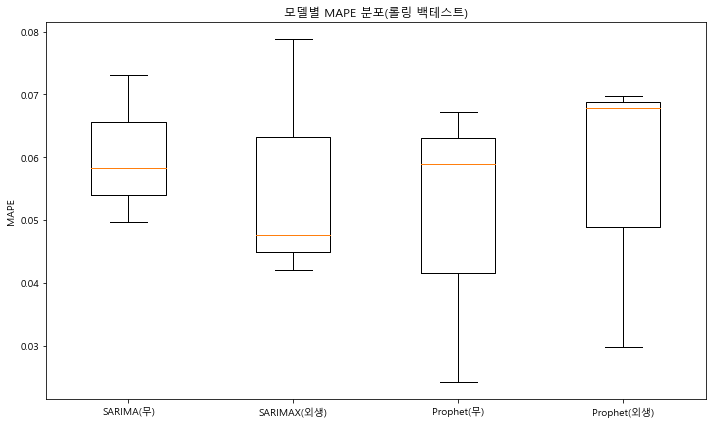

In [ ]:
import pandas as pd
import numpy as np
import itertools
import warnings
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

from prophet import Prophet

warnings.filterwarnings("ignore")

# ============= 공통 설정 =============
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

file_path = r"C:\Users\vpsxl\Desktop\무역학회지 8월호\data.xlsx"
save_dir  = r"C:\Users\vpsxl\Desktop\무역학회지 8월호"

# ============= 데이터 로드 & 전처리 =============
df = pd.read_excel(file_path, sheet_name="데이터")
df["Date"] = pd.to_datetime(df[["year","month"]].assign(DAY=1))
df.set_index("Date", inplace=True)

# 공항(y) 이상치 보정 (2020-01 ~ 2021-12을 선형추세로 대체)
y = df["airport"].astype(float).copy()
mask_out = (y.index >= "2020-01-01") & (y.index <= "2021-12-31")
X = np.arange(len(y)).reshape(-1,1)
lr = LinearRegression().fit(X[~mask_out], y[~mask_out])
y_corr = y.copy()
y_corr[mask_out] = lr.predict(X[mask_out])

# 외생변수 x (제주항)
x = df["port"].astype(float).copy()

# ============= 유틸 =============
def grid_best_sarimax(y_tr, exog_tr=None, d=1, s=12):
    """첫 폴드에서만 AIC 최소 모형을 고르고, 이후 폴드에 재사용"""
    best_aic = np.inf
    best_cfg = None
    best_res = None
    for p, q in itertools.product(range(3), repeat=2):       # 0~2
        for P, Q in itertools.product(range(2), repeat=2):   # 0~1
            try:
                m = SARIMAX(y_tr, exog=exog_tr,
                            order=(p,d,q), seasonal_order=(P,0,Q,s),
                            enforce_stationarity=False, enforce_invertibility=False)
                r = m.fit(disp=False)
                if r.aic < best_aic:
                    best_aic, best_cfg, best_res = r.aic, ((p,d,q),(P,0,Q,s)), r
            except Exception:
                continue
    return best_res, best_cfg, best_aic

def fit_sarimax_with_cfg(y_tr, exog_tr, cfg):
    (p,d,q),(P,D,Q,s) = cfg
    m = SARIMAX(y_tr, exog=exog_tr, order=(p,d,q), seasonal_order=(P,D,Q,s),
                enforce_stationarity=False, enforce_invertibility=False)
    r = m.fit(disp=False)
    return r

# ============= 롤링 백테스트 설정 =============
H = 12          # 테스트(예측) horizon: 12개월
N_SPLITS = 4    # 폴드 수 (데이터 길이에 맞춰 조절)

dates = y_corr.index.sort_values()
n = len(dates)

# 최소 학습길이(충분히 크게): 전체의 ~60% 권장
min_train = int(n * 0.6)

# 각 폴드의 컷오프(예측 시작점) 계산
cutoffs = []
start = min_train
while start + H <= n and len(cutoffs) < N_SPLITS:
    cutoffs.append(dates[start])
    start += H   # horizon 간격으로 롤링

if not cutoffs:
    raise ValueError("폴드가 생성되지 않았습니다. 데이터 길이/파라미터(H, N_SPLITS)를 조정하세요.")

# ============= 백테스트 루프 =============
records = []  # (model, fold_idx, mape, rmse, insample_rmse, cfg)
best_cfg_noexog = None
best_cfg_exog   = None

for i, cutoff in enumerate(cutoffs, 1):
    # 학습/검증 분리
    train_end = cutoff - pd.offsets.MonthBegin(0)  # cutoff 이전까지 학습
    y_tr = y_corr.loc[:train_end]
    y_te = y_corr.loc[cutoff: cutoff + pd.DateOffset(months=H-1)]
    x_tr = x.loc[y_tr.index]
    x_te = x.loc[y_te.index]

    # --- SARIMA(무) ---
    if i == 1:
        res_noexog, best_cfg_noexog, aic_no = grid_best_sarimax(y_tr, exog_tr=None, d=1, s=12)
    else:
        res_noexog = fit_sarimax_with_cfg(y_tr, None, best_cfg_noexog)

    pred_noexog = res_noexog.get_forecast(steps=len(y_te)).predicted_mean
    mape_no = mean_absolute_percentage_error(y_te, pred_noexog)
    rmse_no = mean_squared_error(y_te, pred_noexog, squared=False)
    ins_rmse_no = np.sqrt(np.mean(res_noexog.resid ** 2))

    records.append(["SARIMA(무)", i, mape_no, rmse_no, ins_rmse_no, str(best_cfg_noexog)])

    # --- SARIMAX(외생) ---
    if i == 1:
        res_exog, best_cfg_exog, aic_ex = grid_best_sarimax(y_tr, exog_tr=x_tr, d=1, s=12)
    else:
        res_exog = fit_sarimax_with_cfg(y_tr, x_tr, best_cfg_exog)

    pred_exog = res_exog.get_forecast(steps=len(y_te), exog=x_te).predicted_mean
    mape_ex = mean_absolute_percentage_error(y_te, pred_exog)
    rmse_ex = mean_squared_error(y_te, pred_exog, squared=False)
    ins_rmse_ex = np.sqrt(np.mean(res_exog.resid ** 2))

    records.append(["SARIMAX(외생)", i, mape_ex, rmse_ex, ins_rmse_ex, str(best_cfg_exog)])

    # --- Prophet(무) ---
    df_tr = pd.DataFrame({"ds": y_tr.index, "y": y_tr.values})
    df_te = pd.DataFrame({"ds": y_te.index})
    pm = Prophet(yearly_seasonality=True)
    pm.fit(df_tr)
    p_no = pm.predict(df_te)
    mape_p_no = mean_absolute_percentage_error(y_te, p_no["yhat"])
    rmse_p_no = mean_squared_error(y_te, p_no["yhat"], squared=False)
    # Prophet in-sample RMSE는 직접 계산(학습 기간 예측)
    fit_in = pm.predict(pd.DataFrame({"ds": y_tr.index}))
    ins_rmse_p_no = mean_squared_error(y_tr, fit_in["yhat"], squared=False)
    records.append(["Prophet(무)", i, mape_p_no, rmse_p_no, ins_rmse_p_no, "-"])

    # --- Prophet(외생) ---
    df_tr_ex = pd.merge(df_tr,
                        x_tr.reset_index().rename(columns={"Date":"ds","port":"exog"}),
                        on="ds")
    pmx = Prophet(yearly_seasonality=True)
    pmx.add_regressor("exog")
    pmx.fit(df_tr_ex)
    df_te_ex = pd.merge(df_te,
                        x_te.reset_index().rename(columns={"Date":"ds","port":"exog"}),
                        on="ds")
    p_ex = pmx.predict(df_te_ex)
    mape_p_ex = mean_absolute_percentage_error(y_te, p_ex["yhat"])
    rmse_p_ex = mean_squared_error(y_te, p_ex["yhat"], squared=False)
    fit_in_ex = pmx.predict(pd.merge(pd.DataFrame({"ds": y_tr.index}),
                        x_tr.reset_index().rename(columns={"Date":"ds","port":"exog"}), on="ds"))
    ins_rmse_p_ex = mean_squared_error(y_tr, fit_in_ex["yhat"], squared=False)
    records.append(["Prophet(외생)", i, mape_p_ex, rmse_p_ex, ins_rmse_p_ex, "-"])

# 결과표 정리
cv_df = pd.DataFrame(records, columns=["model","fold","MAPE","RMSE","InSample_RMSE","config"])
summary = (cv_df.groupby("model")[["MAPE","RMSE","InSample_RMSE"]]
           .agg(["mean","std","min","max"]).round(4))

print("\n[롤링 백테스트 결과(폴드별)]")
print(cv_df.to_string(index=False))
print("\n[모델별 요약 통계]")
print(summary)

# 저장
cv_df.to_csv(fr"{save_dir}\overfit_cv_folds.csv", index=False, encoding="utf-8-sig")
summary.to_csv(fr"{save_dir}\overfit_cv_summary.csv", encoding="utf-8-sig")

# ============= 과적합 진단 포인트 =============
# 1) InSample_RMSE << RMSE 이면 과적합 의심
print("\n[과적합 힌트] In-sample RMSE와 OOS RMSE 차이(최근 폴드)")
for m in cv_df["model"].unique():
    last = cv_df[cv_df["model"]==m].sort_values("fold").iloc[-1]
    gap = last["InSample_RMSE"] - last["RMSE"]
    print(f"{m}: In-sample {last['InSample_RMSE']:.2f} vs OOS {last['RMSE']:.2f} | 차이={gap:.2f}")

# 2) 마지막 폴드 잔차 Ljung-Box (SARIMA/SARIMAX)
#    잔차에 자기상관이 남아있으면 모형 과소적합/부적합 가능
lb_no = acorr_ljungbox(res_noexog.resid, lags=[10], return_df=True)
lb_ex = acorr_ljungbox(res_exog.resid,  lags=[10], return_df=True)
print("\n[Ljung-Box p-value (잔차 자기상관 검정, 마지막 폴드 기준)]")
print(f"SARIMA(무): p={lb_no['lb_pvalue'].values[0]:.4f}")
print(f"SARIMAX(외생): p={lb_ex['lb_pvalue'].values[0]:.4f}")

# ============= 시 بص각화: 모델별 오류 분포 박스플롯 =============
plt.figure(figsize=(10,6))
labels = []
data_mape = []
for m in ["SARIMA(무)","SARIMAX(외생)","Prophet(무)","Prophet(외생)"]:
    labels.append(m)
    data_mape.append(cv_df[cv_df["model"]==m]["MAPE"].values)

plt.boxplot(data_mape, labels=labels)
plt.title("모델별 MAPE 분포(롤링 백테스트)")
plt.ylabel("MAPE")
plt.tight_layout()
plt.savefig(fr"{save_dir}\overfit_mape_boxplot.png", dpi=300)
plt.show()


# test 끝


✅ SARIMAX(외생) 최적 파라미터: (2, 2, 2)
✅ SARIMAX(무) 최적 파라미터: (1, 2, 2)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



📌 SARIMAX AIC 비교
SARIMAX(외생): AIC = 1633.28
SARIMAX(무)  : AIC = 1654.15

📌 Ljung-Box 테스트 (잔차의 자기상관 검정)
SARIMAX(외생): p-value = 0.5059
SARIMAX(무)  : p-value = 0.6058

✅ 테스트 성능 비교 (MAPE / RMSE)
SARIMAX(외생)   MAPE=0.0680, RMSE=1249.15
SARIMAX(무)     MAPE=0.0677, RMSE=1324.77
Prophet(외생)   MAPE=0.0585, RMSE=1166.66
Prophet(무)     MAPE=0.0631, RMSE=1271.47


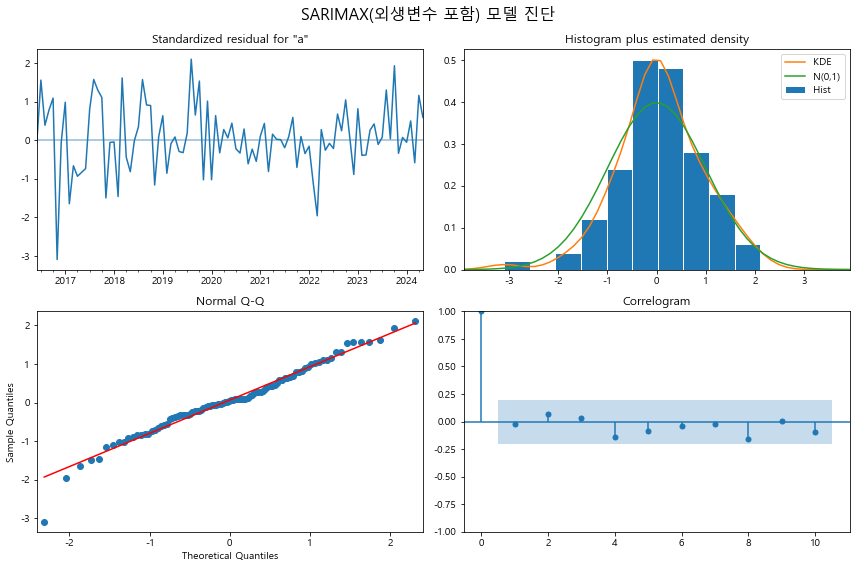

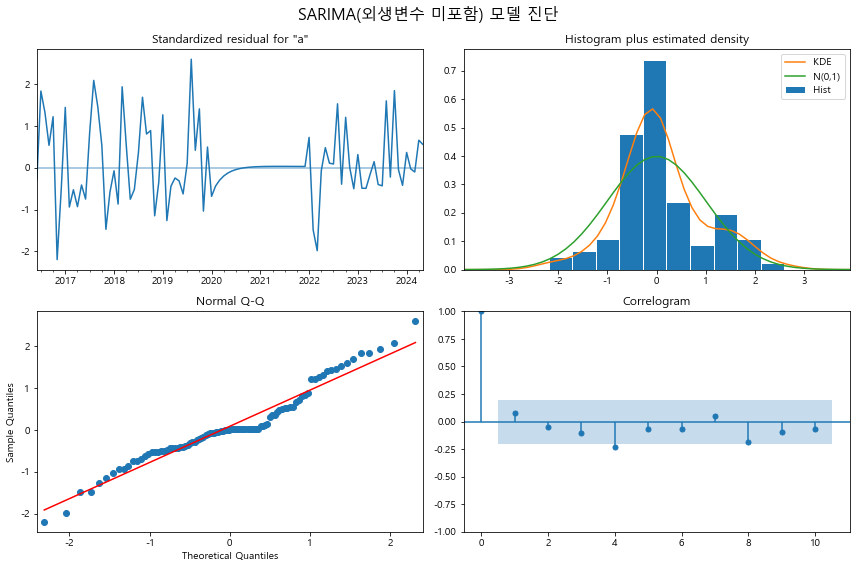

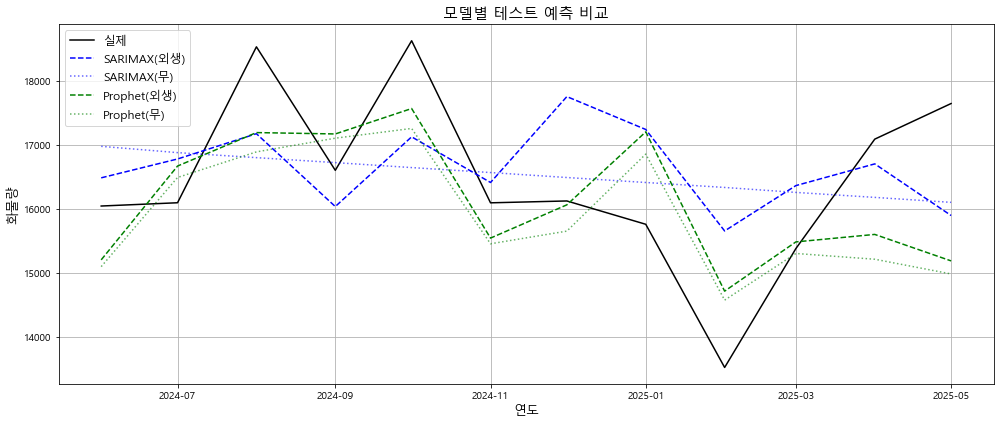

In [ ]:
import pandas as pd
import numpy as np
import itertools
import warnings
import os
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from prophet import Prophet

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 불러오기
file_path = r"C:\Users\vpsxl\Desktop\무역학회지 8월호\data.xlsx"
df = pd.read_excel(file_path, sheet_name="데이터")
df["Date"] = pd.to_datetime(df[["year", "month"]].assign(DAY=1))
df.set_index("Date", inplace=True)

# 2. 이상치 보정
y = df["airport"].astype(float).copy()
outlier_period = (y.index >= "2020-01-01") & (y.index <= "2021-12-31")
X = np.arange(len(y)).reshape(-1, 1)
X_no_outlier = X[~outlier_period]
y_no_outlier = y[~outlier_period]
model_lr = LinearRegression()
model_lr.fit(X_no_outlier, y_no_outlier)
y_pred_outlier = model_lr.predict(X[outlier_period])
y_corrected = y.copy()
y_corrected[outlier_period] = y_pred_outlier

# 3. 학습/테스트 분할
n_test = 12
y_train = y_corrected.iloc[:-n_test]
y_test = y_corrected.iloc[-n_test:]
exog_train = df["port"].iloc[:-n_test]
exog_test = df["port"].iloc[-n_test:]

# 4. SARIMAX 파라미터 탐색
p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))
aic_results_exog = []
aic_results_noexog = []
warnings.filterwarnings("ignore")

# 외생 포함
for param in pdq:
    try:
        model = SARIMAX(y_train, exog=exog_train, order=param,
                        enforce_stationarity=False, enforce_invertibility=False)
        result = model.fit(disp=False)
        aic_results_exog.append((param, result.aic))
    except:
        continue
best_param_exog = sorted(aic_results_exog, key=lambda x: x[1])[0][0]

# 외생 미포함
for param in pdq:
    try:
        model = SARIMAX(y_train, order=param,
                        enforce_stationarity=False, enforce_invertibility=False)
        result = model.fit(disp=False)
        aic_results_noexog.append((param, result.aic))
    except:
        continue
best_param_noexog = sorted(aic_results_noexog, key=lambda x: x[1])[0][0]

print(f"\n✅ SARIMAX(외생) 최적 파라미터: {best_param_exog}")
print(f"✅ SARIMAX(무) 최적 파라미터: {best_param_noexog}")

# 5. 최종 모델 학습
sarimax_model_exog = SARIMAX(y_train, exog=exog_train, order=best_param_exog,
                             enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarimax_model_noexog = SARIMAX(y_train, order=best_param_noexog,
                               enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

# 6. 예측
sarimax_pred_exog = sarimax_model_exog.get_forecast(steps=n_test, exog=exog_test).predicted_mean
sarimax_pred_noexog = sarimax_model_noexog.get_forecast(steps=n_test).predicted_mean

# 7. Prophet 준비 및 예측
prophet_df = pd.DataFrame({"ds": y_train.index, "y": y_train.values})
prophet_exog_train = exog_train.reset_index().rename(columns={"Date":"ds", "port":"exog"})

# Prophet 외생 포함
prophet_model_exog = Prophet()
prophet_model_exog.add_regressor("exog")
prophet_train_data = pd.merge(prophet_df, prophet_exog_train, on="ds")
prophet_model_exog.fit(prophet_train_data)
future = pd.DataFrame({"ds": y_test.index})
future_exog = exog_test.reset_index().rename(columns={"Date":"ds", "port":"exog"})
future_all = pd.merge(future, future_exog, on="ds")
prophet_pred_exog = prophet_model_exog.predict(future_all)

# Prophet 외생 미포함
prophet_model_noexog = Prophet()
prophet_model_noexog.fit(prophet_df)
prophet_pred_noexog = prophet_model_noexog.predict(future)

# 8. 성능평가
mape_sarimax_exog = mean_absolute_percentage_error(y_test, sarimax_pred_exog)
rmse_sarimax_exog = mean_squared_error(y_test, sarimax_pred_exog, squared=False)

mape_sarimax_noexog = mean_absolute_percentage_error(y_test, sarimax_pred_noexog)
rmse_sarimax_noexog = mean_squared_error(y_test, sarimax_pred_noexog, squared=False)

mape_prophet_exog = mean_absolute_percentage_error(y_test, prophet_pred_exog["yhat"])
rmse_prophet_exog = mean_squared_error(y_test, prophet_pred_exog["yhat"], squared=False)

mape_prophet_noexog = mean_absolute_percentage_error(y_test, prophet_pred_noexog["yhat"])
rmse_prophet_noexog = mean_squared_error(y_test, prophet_pred_noexog["yhat"], squared=False)

# 9. 적합성 검증 (AIC, Ljung-Box)
print("\n📌 SARIMAX AIC 비교")
print(f"SARIMAX(외생): AIC = {sarimax_model_exog.aic:.2f}")
print(f"SARIMAX(무)  : AIC = {sarimax_model_noexog.aic:.2f}")

lb_exog = acorr_ljungbox(sarimax_model_exog.resid, lags=[10], return_df=True)
lb_noexog = acorr_ljungbox(sarimax_model_noexog.resid, lags=[10], return_df=True)

print("\n📌 Ljung-Box 테스트 (잔차의 자기상관 검정)")
print(f"SARIMAX(외생): p-value = {lb_exog['lb_pvalue'].values[0]:.4f}")
print(f"SARIMAX(무)  : p-value = {lb_noexog['lb_pvalue'].values[0]:.4f}")

print("\n✅ 테스트 성능 비교 (MAPE / RMSE)")
print(f"SARIMAX(외생)   MAPE={mape_sarimax_exog:.4f}, RMSE={rmse_sarimax_exog:.2f}")
print(f"SARIMAX(무)     MAPE={mape_sarimax_noexog:.4f}, RMSE={rmse_sarimax_noexog:.2f}")
print(f"Prophet(외생)   MAPE={mape_prophet_exog:.4f}, RMSE={rmse_prophet_exog:.2f}")
print(f"Prophet(무)     MAPE={mape_prophet_noexog:.4f}, RMSE={rmse_prophet_noexog:.2f}")

# 10. SARIMAX 진단 플롯 (잔차 분석)
sarimax_model_exog.plot_diagnostics(figsize=(12, 8))
plt.suptitle("SARIMAX(외생변수 포함) 모델 진단", fontsize=16)
plt.tight_layout()

# 5. 저장
save_path = r"C:\Users\vpsxl\Desktop\무역학회지 8월호\SARIMA(외생 포함).png"
plt.savefig(save_path, dpi=300)
plt.show()

sarimax_model_noexog.plot_diagnostics(figsize=(12, 8))
plt.suptitle("SARIMA(외생변수 미포함) 모델 진단", fontsize=16)
plt.tight_layout()
save_path = r"C:\Users\vpsxl\Desktop\무역학회지 8월호\SARIMA(외생 미포함).png"
plt.savefig(save_path, dpi=300)
plt.show()

plt.show()

# 11. 예측 시각화
plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test, label="실제", color='black')
plt.plot(y_test.index, sarimax_pred_exog, label="SARIMAX(외생)", linestyle="--", color='blue')
plt.plot(y_test.index, sarimax_pred_noexog, label="SARIMAX(무)", linestyle=":", color='blue', alpha=0.6)
plt.plot(y_test.index, prophet_pred_exog["yhat"], label="Prophet(외생)", linestyle="--", color='green')
plt.plot(y_test.index, prophet_pred_noexog["yhat"], label="Prophet(무)", linestyle=":", color='green', alpha=0.6)
plt.title("모델별 테스트 예측 비교", fontsize=15)
plt.xlabel("연도", fontsize=13)
plt.ylabel("화물량", fontsize=13)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()


# 5. 저장
save_path = r"C:\Users\vpsxl\Desktop\무역학회지 8월호\모델 비교.png"
plt.savefig(save_path, dpi=300)
plt.show()

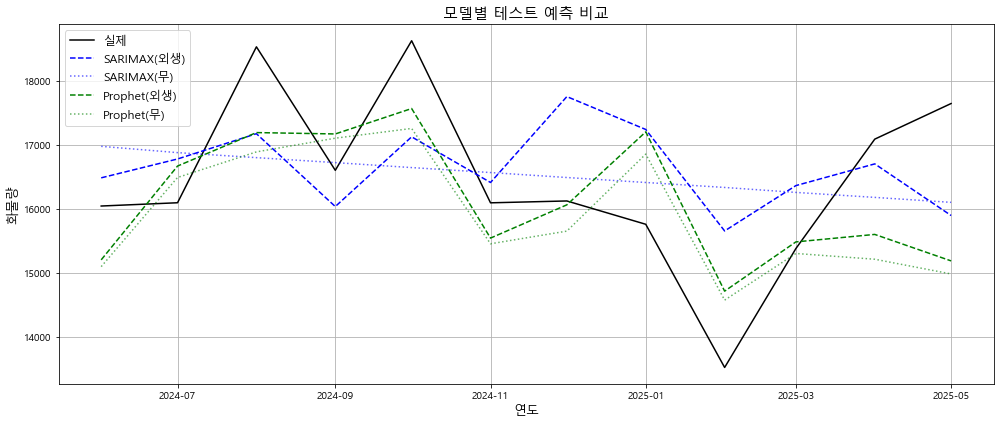

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test, label="실제", color='black')
plt.plot(y_test.index, sarimax_pred_exog, label="SARIMAX(외생)", linestyle="--", color='blue')
plt.plot(y_test.index, sarimax_pred_noexog, label="SARIMAX(무)", linestyle=":", color='blue', alpha=0.6)
plt.plot(y_test.index, prophet_pred_exog["yhat"], label="Prophet(외생)", linestyle="--", color='green')
plt.plot(y_test.index, prophet_pred_noexog["yhat"], label="Prophet(무)", linestyle=":", color='green', alpha=0.6)  # 👈 여기에 방금 prophet_pred_noexog 결과를 사용!
plt.title("모델별 테스트 예측 비교", fontsize=15)
plt.xlabel("연도", fontsize=13)
plt.ylabel("화물량", fontsize=13)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()

plt.savefig(r"C:\Users\vpsxl\Desktop\무역학회지 8월호\모델 비교(Prophet무 단독 예측 반영).png", dpi=300)
plt.show()

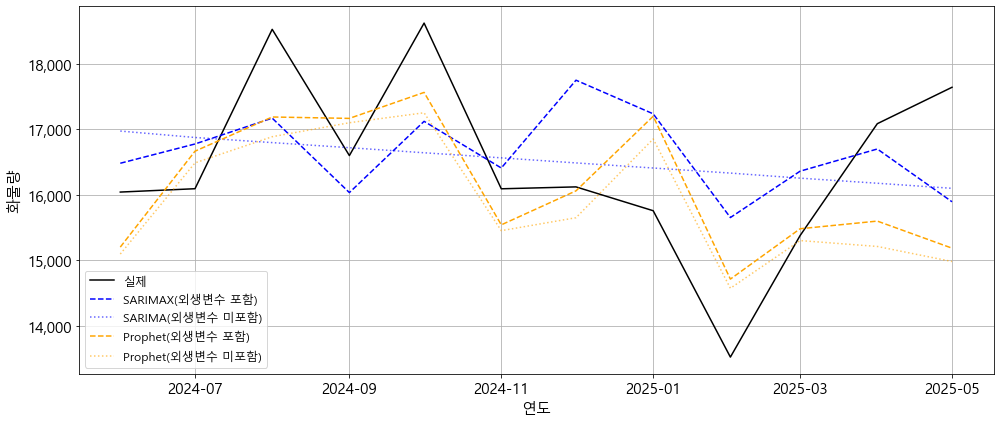

In [ ]:
# 11. 예측 시각화
plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test, label="실제", color='black')
plt.plot(y_test.index, sarimax_pred_exog, label="SARIMAX(외생변수 포함)", linestyle="--", color='blue')
plt.plot(y_test.index, sarimax_pred_noexog, label="SARIMA(외생변수 미포함)", linestyle=":", color='blue', alpha=0.6)
plt.plot(y_test.index, prophet_pred_exog["yhat"], label="Prophet(외생변수 포함)", linestyle="--", color='orange')
plt.plot(y_test.index, prophet_pred_noexog["yhat"], label="Prophet(외생변수 미포함)", linestyle=":", color='orange', alpha=0.6)
plt.xlabel("연도", fontsize=15)
plt.ylabel("화물량", fontsize=15)
plt.legend(fontsize=12)
plt.grid(True)

# 눈금 폰트 크기 설정
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# y축 천단위 컴마
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: format(int(x), ',')))

plt.tight_layout()

# 5. 저장
save_path = r"C:\Users\vpsxl\Desktop\무역학회지 8월호\모델 비교.png"
plt.savefig(save_path, dpi=500)
plt.show()

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


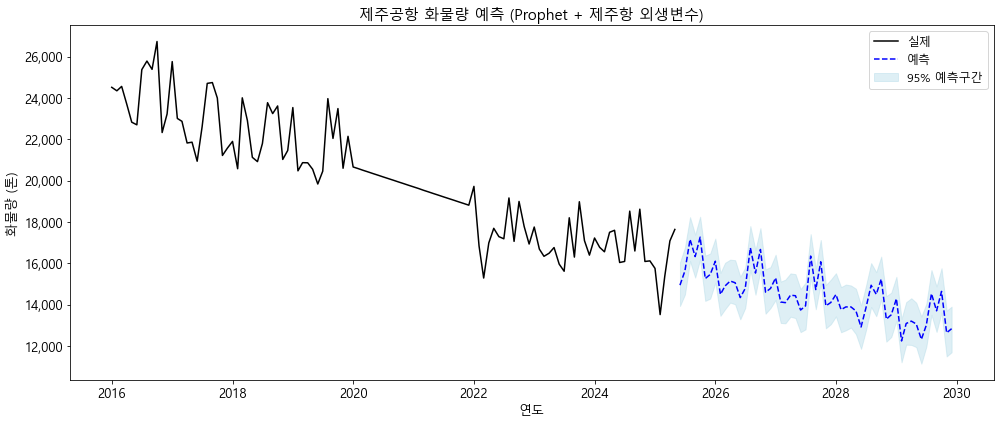

In [ ]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# -------------------------------------
# 1. 데이터 불러오기
# -------------------------------------
file_path = r"C:\Users\vpsxl\Desktop\무역학회지 8월호\data.xlsx"
df = pd.read_excel(file_path, sheet_name="데이터")
df["Date"] = pd.to_datetime(df[["year", "month"]].assign(DAY=1))
df.set_index("Date", inplace=True)

# -------------------------------------
# 2. 이상치 보정 (공항 데이터 기준)
# -------------------------------------
y_airport = df["airport"].astype(float).copy()
outlier_period = (y_airport.index >= "2020-01-01") & (y_airport.index <= "2021-12-31")
X = np.arange(len(y_airport)).reshape(-1, 1)
X_no_outlier = X[~outlier_period]
y_no_outlier = y_airport[~outlier_period]
model_lr = LinearRegression()
model_lr.fit(X_no_outlier, y_no_outlier)
y_pred_outlier = model_lr.predict(X[outlier_period])
y_airport[outlier_period] = y_pred_outlier

# -------------------------------------
# 3. 제주항 물동량 예측 (Prophet)
# -------------------------------------
port_df = pd.DataFrame({
    "ds": df.index,
    "y": df["port"].values
})
port_model = Prophet()
port_model.fit(port_df)

# 미래 날짜 생성 (2029년 12월까지)
future_dates = pd.date_range(start=df.index[-1] + pd.offsets.MonthBegin(), end="2029-12-01", freq="MS")
future_port = pd.DataFrame({"ds": future_dates})

# 제주항 예측
forecast_port = port_model.predict(future_port)
port_predicted = pd.concat([
    pd.DataFrame({"ds": df.index, "y": df["port"].values}),
    forecast_port[["ds", "yhat"]].rename(columns={"yhat": "y"})
])
port_predicted.set_index("ds", inplace=True)

# -------------------------------------
# 4. 제주공항 화물량 예측 (Prophet with 외생변수)
# -------------------------------------
# 학습 데이터 준비
airport_df = pd.DataFrame({
    "ds": df.index,
    "y": y_airport.values,
    "exog": df["port"].values
})

# Prophet 모델 학습
airport_model = Prophet()
airport_model.add_regressor("exog")
airport_model.fit(airport_df)

# 미래 데이터 준비 (제주항 예측 결과 활용)
future_airport = pd.DataFrame({
    "ds": future_dates,
    "exog": forecast_port["yhat"].values
})

# 예측
forecast_airport = airport_model.predict(future_airport)

# -------------------------------------
# 5. 결과 저장 및 시각화
# -------------------------------------
# 결과 저장
result_df = forecast_airport[["ds", "yhat", "yhat_lower", "yhat_upper"]]
result_df.to_excel(r"C:\Users\vpsxl\Desktop\무역학회지 8월호\제주공항_예측결과_외생포함.xlsx", index=False)

# 시각화
plt.figure(figsize=(14, 6))
plt.plot(df.index, y_airport, label="실제", color="black")
plt.plot(result_df["ds"], result_df["yhat"], label="예측", linestyle="--", color="blue")
plt.fill_between(result_df["ds"], result_df["yhat_lower"], result_df["yhat_upper"],
                 color="lightblue", alpha=0.4, label="95% 예측구간")

plt.title("제주공항 화물량 예측 (Prophet + 제주항 외생변수)", fontsize=15)
plt.xlabel("연도", fontsize=13)
plt.ylabel("화물량 (톤)", fontsize=13)
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format(int(x), ",")))
ax.tick_params(axis='both', labelsize=13)
plt.legend(fontsize=12)
plt.tight_layout()

# 저장
plt.savefig(r"C:\Users\vpsxl\Desktop\무역학회지 8월호\제주공항_예측그래프_외생포함.png", dpi=300)
plt.show()


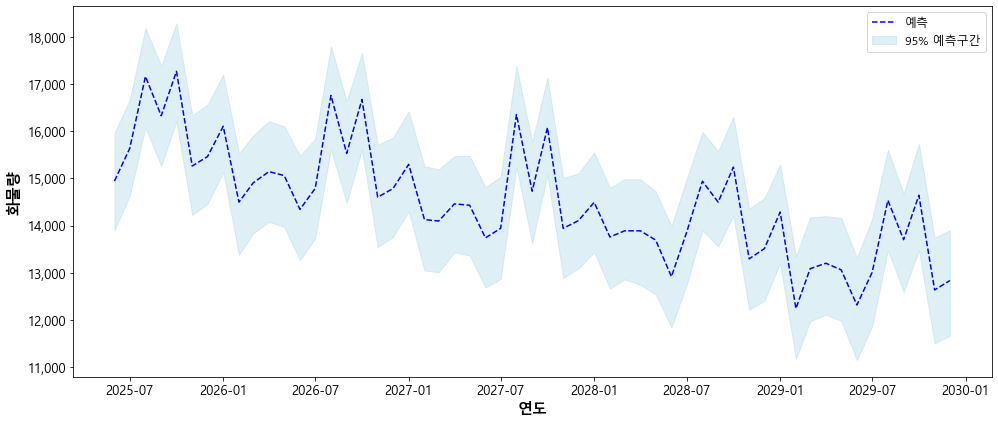

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 예측 시작 시점 지정
start_date = "2025-06-01"
forecast_period = result_df[result_df["ds"] >= start_date]

# 시각화
plt.figure(figsize=(14, 6))
plt.plot(forecast_period["ds"], forecast_period["yhat"], label="예측", linestyle="--", color="blue")
plt.fill_between(
    forecast_period["ds"],
    forecast_period["yhat_lower"],
    forecast_period["yhat_upper"],
    color="lightblue", alpha=0.4, label="95% 예측구간"
)

plt.xlabel("연도", fontsize=15, fontweight='bold')
plt.ylabel("화물량", fontsize=15, fontweight='bold')

# 천단위 콤마 + 폰트크기
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format(int(x), ",")))
ax.tick_params(axis='both', labelsize=13)

plt.legend(fontsize=12)
plt.tight_layout()

# 저장
plt.savefig(r"C:\Users\vpsxl\Desktop\무역학회지 8월호\제주공항_예측구간_그래프.png", dpi=300)
plt.show()


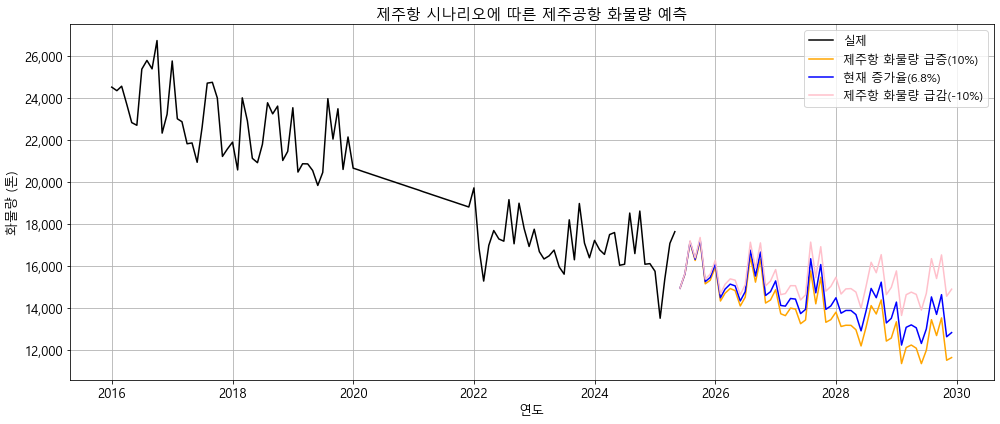

In [ ]:
# -------------------------------------
# 6. 시나리오 정의 및 적용 (역방향: 항만 증가 → 공항 감소)
# -------------------------------------
scenario_growth_rates = {
    "제주항 화물량 급증(10%)": 1.10,
    "현재 증가율(6.8%)": 1.00,
    "제주항 화물량 급감(-10%)": 0.90
}

scenario_forecasts = {}

for label, annual_growth in scenario_growth_rates.items():
    # 월간 역성장률 계산 (항만 성장 → 공항 감소)
    monthly_growth = annual_growth ** (1 / 12)
    months = len(future_dates)

    # 역성장률 → 제주항 yhat에 적용 (반대로 영향)
    growth_factors = np.array([1 / (monthly_growth ** i) for i in range(months)])

    # 시나리오 반영한 외생변수 생성
    scenario_exog = forecast_port["yhat"].values * growth_factors
    future_scenario = pd.DataFrame({
        "ds": future_dates,
        "exog": scenario_exog
    })

    # 공항 예측
    forecast = airport_model.predict(future_scenario)
    forecast["시나리오"] = label
    scenario_forecasts[label] = forecast[["ds", "yhat", "시나리오"]]

# -------------------------------------
# 7. 시각화
# -------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(df.index, y_airport, label="실제", color="black")

colors = {
    "제주항 화물량 급증(10%)": "orange",
    "현재 증가율(6.8%)": "blue",
    "제주항 화물량 급감(-10%)": "pink"
}

for label, forecast in scenario_forecasts.items():
    plt.plot(forecast["ds"], forecast["yhat"], label=label, linestyle="-", color=colors[label])

plt.title("제주항 시나리오에 따른 제주공항 화물량 예측", fontsize=15)
plt.xlabel("연도", fontsize=13)
plt.ylabel("화물량 (톤)", fontsize=13)
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format(int(x), ",")))
ax.tick_params(axis='both', labelsize=13)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\vpsxl\Desktop\무역학회지 8월호\제주공항_시나리오별예측.png", dpi=300)
plt.show()

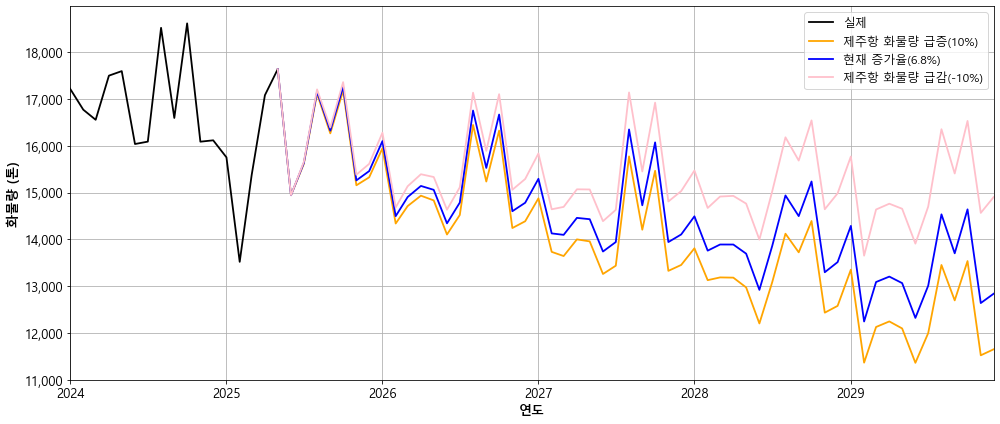

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# -------------------------------------
# 시각화: 연결된 선 & 2024년 이후만 표시
# -------------------------------------
plt.figure(figsize=(14, 6))

# 필터: 2024년 1월 이후
filter_start = pd.to_datetime("2024-01-01")
actual_filtered = df[df.index >= filter_start]
y_airport_filtered = y_airport[actual_filtered.index]

# 실측값 시각화
plt.plot(actual_filtered.index, y_airport_filtered, label="실제", color="black", linewidth=1.8)

# 시나리오별 선 그리기
colors = {
    "제주항 화물량 급증(10%)": "orange",
    "현재 증가율(6.8%)": "blue",
    "제주항 화물량 급감(-10%)": "pink"
}

for label, forecast in scenario_forecasts.items():
    forecast_filtered = forecast[forecast["ds"] >= filter_start]
    # 이어지게 하기 위해 실측 마지막점 추가
    last_real_date = y_airport_filtered.index[-1]
    last_real_value = y_airport_filtered.iloc[-1]
    ds_extended = pd.concat([pd.Series([last_real_date]), forecast_filtered["ds"]])
    y_extended = pd.concat([pd.Series([last_real_value]), forecast_filtered["yhat"]])

    plt.plot(ds_extended, y_extended, label=label, color=colors[label], linestyle="-", linewidth=1.8)

# -------------------------------------
# 설정
# -------------------------------------
plt.xlabel("연도", fontsize=13, fontweight ='bold')
plt.ylabel("화물량 (톤)", fontsize=13, fontweight ='bold')

ax = plt.gca()
ax.set_xlim([filter_start, forecast["ds"].max()])
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format(int(x), ",")))
ax.tick_params(axis='both', labelsize=13)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()

# 저장 및 표시
plt.savefig(r"C:\Users\vpsxl\Desktop\무역학회지 8월호\제주공항_예측연결_2024이후.png", dpi=300)
plt.show()


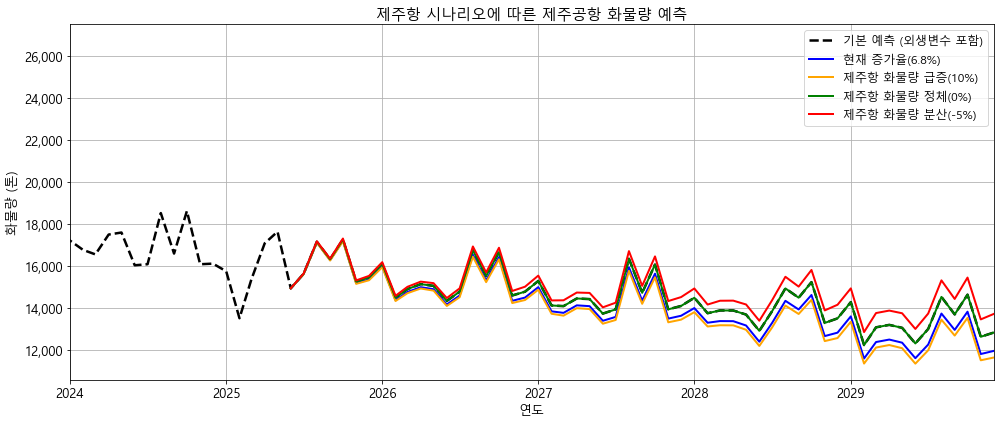

In [ ]:
# -------------------------------------
# 7. 시각화 (2024년 이후, 기본 예측 포함)
# -------------------------------------
plt.figure(figsize=(14, 6))

# 전체 기간: 실제 + 기본 예측 연결
full_dates = pd.concat([df.index.to_series(), result_df["ds"]])
full_airport = pd.concat([y_airport, result_df["yhat"]])

# 기본 예측 선 먼저 그림 (굵게, 진한 색)
plt.plot(full_dates, full_airport, label="기본 예측 (외생변수 포함)", linestyle="--", color="black", linewidth=2.5)

# 시나리오 예측 선 추가
colors = {
    "현재 증가율(6.8%)": "blue",
    "제주항 화물량 급증(10%)": "orange",
    "제주항 화물량 정체(0%)": "green",
    "제주항 화물량 분산(-5%)": "red"
}

for label, forecast in scenario_forecasts.items():
    plt.plot(forecast["ds"], forecast["yhat"], label=label, linestyle="-", color=colors[label], linewidth=2)

# 시각화 설정
plt.title("제주항 시나리오에 따른 제주공항 화물량 예측", fontsize=15)
plt.xlabel("연도", fontsize=13)
plt.ylabel("화물량 (톤)", fontsize=13)
ax = plt.gca()
ax.set_xlim([pd.Timestamp("2024-01-01"), pd.Timestamp("2029-12-01")])
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format(int(x), ",")))
ax.tick_params(axis='both', labelsize=13)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()

# 저장 및 출력
plt.savefig(r"C:\Users\vpsxl\Desktop\무역학회지 8월호\제주공항_시나리오_최종.png", dpi=300)
plt.show()


In [ ]:
# 마지막 1년 필터링 (2029년 1월 ~ 2029년 12월)
last_year_df = scenario_all_df[
    (scenario_all_df["ds"] >= "2027-01-01") & (scenario_all_df["ds"] <= "2027-5-31")
]

# 결과 출력
print(last_year_df)

# 엑셀 저장 (선택)
last_year_df.to_excel(
    r"C:\Users\vpsxl\Desktop\무역학회지 8월호\제주공항_시나리오_2029년_예측결과.xlsx",
    index=False
)

           ds          yhat             시나리오
19 2027-01-01  14879.218135  제주항 화물량 급증(10%)
19 2027-01-01  15549.711936  제주항 화물량 분산(-5%)
19 2027-01-01  15297.233037   제주항 화물량 정체(0%)
19 2027-01-01  15002.022365     현재 증가율(6.8%)
20 2027-02-01  13734.431914  제주항 화물량 급증(10%)
20 2027-02-01  14369.176545  제주항 화물량 분산(-5%)
20 2027-02-01  14129.259164   제주항 화물량 정체(0%)
20 2027-02-01  13850.095854     현재 증가율(6.8%)
21 2027-03-01  13645.122517  제주항 화물량 급증(10%)
21 2027-03-01  14375.763451  제주항 화물량 분산(-5%)
21 2027-03-01  14098.562761   제주항 화물량 정체(0%)
21 2027-03-01  13777.580508     현재 증가율(6.8%)
22 2027-04-01  14001.618924  제주항 화물량 급증(10%)
22 2027-04-01  14744.179927  제주항 화물량 분산(-5%)
22 2027-04-01  14461.402101   제주항 화물량 정체(0%)
22 2027-04-01  14135.548458     현재 증가율(6.8%)
23 2027-05-01  13958.681625  제주항 화물량 급증(10%)
23 2027-05-01  14726.617567  제주항 화물량 분산(-5%)
23 2027-05-01  14433.084931   제주항 화물량 정체(0%)
23 2027-05-01  14096.476830     현재 증가율(6.8%)


In [ ]:
# 2029년 예측치 필터링
last_year_forecast = result_df[
    (result_df["ds"] >= "2027-01-01") & (result_df["ds"] <= "2027-5-31")
]

# 결과 출력
print(last_year_forecast)

           ds          yhat    yhat_lower    yhat_upper
19 2027-01-01  15297.233037  14230.341329  16419.407922
20 2027-02-01  14129.259164  13115.537973  15117.801199
21 2027-03-01  14098.562761  13099.492783  15210.677076
22 2027-04-01  14461.402101  13418.260646  15514.073566
23 2027-05-01  14433.084931  13353.187584  15476.670893


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


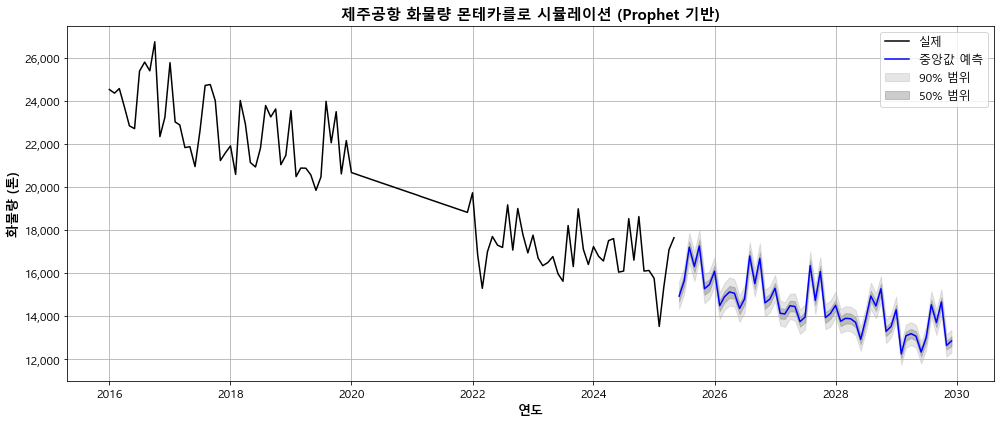

In [ ]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# -------------------------------------
# 1. 데이터 불러오기 및 이상치 보정
# -------------------------------------
file_path = r"C:\Users\vpsxl\Desktop\무역학회지 8월호\data.xlsx"
df = pd.read_excel(file_path, sheet_name="데이터")
df["Date"] = pd.to_datetime(df[["year", "month"]].assign(DAY=1))
df.set_index("Date", inplace=True)

y_airport = df["airport"].astype(float).copy()
outlier_period = (y_airport.index >= "2020-01-01") & (y_airport.index <= "2021-12-31")
X = np.arange(len(y_airport)).reshape(-1, 1)
X_no_outlier = X[~outlier_period]
y_no_outlier = y_airport[~outlier_period]
model_lr = LinearRegression().fit(X_no_outlier, y_no_outlier)
y_airport[outlier_period] = model_lr.predict(X[outlier_period])

# -------------------------------------
# 2. 제주항 외생변수 예측 (Prophet)
# -------------------------------------
port_df = pd.DataFrame({"ds": df.index, "y": df["port"].values})
port_model = Prophet()
port_model.fit(port_df)

future_dates = pd.date_range(start=df.index[-1] + pd.offsets.MonthBegin(), end="2029-12-01", freq="MS")
future_port = pd.DataFrame({"ds": future_dates})
forecast_port = port_model.predict(future_port)

# -------------------------------------
# 3. 제주공항 예측 (Prophet + 외생변수)
# -------------------------------------
airport_df = pd.DataFrame({
    "ds": df.index,
    "y": y_airport.values,
    "exog": df["port"].values
})
airport_model = Prophet()
airport_model.add_regressor("exog")
airport_model.fit(airport_df)

future_airport = pd.DataFrame({
    "ds": future_dates,
    "exog": forecast_port["yhat"].values
})
forecast_airport = airport_model.predict(future_airport)

# -------------------------------------
# 4. 몬테카를로 시뮬레이션
# -------------------------------------
base_yhat = forecast_airport["yhat"].values
n_months = len(base_yhat)
n_simulations = 1000

# 시뮬레이션 오차 설정 (Prophet 불확실성 ±2%~3% 정도)
error_mu = 0
error_sigma = 0.025

simulations = np.zeros((n_months, n_simulations))

for i in range(n_simulations):
    # 무작위 오차 적용
    noise = np.random.normal(error_mu, error_sigma, n_months)
    simulations[:, i] = base_yhat * (1 + noise)

# 퍼센타일 밴드 계산
percentiles = {
    "50%": np.percentile(simulations, 50, axis=1),
    "75%": np.percentile(simulations, 75, axis=1),
    "95%": np.percentile(simulations, 95, axis=1),
    "5%": np.percentile(simulations, 5, axis=1),
    "25%": np.percentile(simulations, 25, axis=1)
}

# -------------------------------------
# 5. 시각화
# -------------------------------------
plt.figure(figsize=(14, 6))

# 과거 데이터
plt.plot(df.index, y_airport, label="실제", color="black")

# 리본형 민감도 영역
plt.fill_between(future_dates, percentiles["5%"], percentiles["95%"], color='gray', alpha=0.2, label="90% 범위")
plt.fill_between(future_dates, percentiles["25%"], percentiles["75%"], color='gray', alpha=0.4, label="50% 범위")

# 중앙값 예측
plt.plot(future_dates, percentiles["50%"], color="blue", label="중앙값 예측")

plt.title("제주공항 화물량 몬테카를로 시뮬레이션 (Prophet 기반)", fontsize=15, fontweight='bold')
plt.xlabel("연도", fontsize=13, fontweight='bold')
plt.ylabel("화물량 (톤)", fontsize=13, fontweight='bold')
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format(int(x), ",")))
ax.tick_params(axis='both', labelsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()

# 저장
plt.savefig(r"C:\Users\vpsxl\Desktop\무역학회지 8월호\제주공항_몬테카를로_시뮬레이션.png", dpi=300)
plt.show()


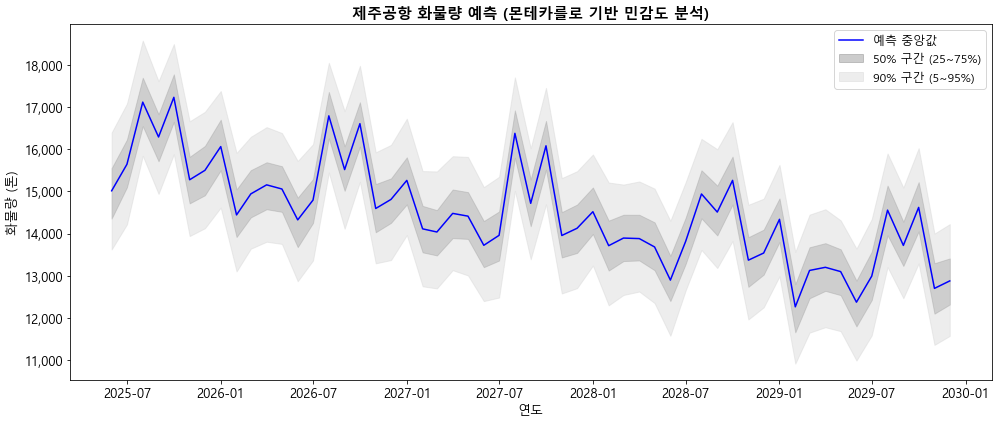

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# -------------------------------------
# 1. 예측 잔차 기반 불확실성 샘플링 (1000회 시뮬레이션)
# -------------------------------------
# 잔차 계산 (과거 학습 구간에서 예측치 - 실제값)
past_df = airport_model.predict(airport_df)
residuals = airport_df["y"].values - past_df["yhat"].values
residual_std = np.std(residuals)

# 예측값 (중앙값) 가져오기
yhat = forecast_airport["yhat"].values
n_forecast = len(yhat)

# 1000회 시뮬레이션 수행
simulations = []
np.random.seed(42)
for _ in range(1000):
    noise = np.random.normal(0, residual_std, n_forecast)
    sim = yhat + noise
    simulations.append(sim)

simulations = np.array(simulations)

# -------------------------------------
# 2. 예측 구간 계산
# -------------------------------------
ds = forecast_airport["ds"]
yhat_median = np.median(simulations, axis=0)
yhat_p05 = np.percentile(simulations, 5, axis=0)
yhat_p25 = np.percentile(simulations, 25, axis=0)
yhat_p75 = np.percentile(simulations, 75, axis=0)
yhat_p95 = np.percentile(simulations, 95, axis=0)

# -------------------------------------
# 3. 리본 형태 시각화
# -------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(ds, yhat_median, label="예측 중앙값", color="blue")

# 리본 형태로 예측 구간 시각화
plt.fill_between(ds, yhat_p25, yhat_p75, color="gray", alpha=0.4, label="50% 구간 (25~75%)")
plt.fill_between(ds, yhat_p05, yhat_p95, color="lightgray", alpha=0.4, label="90% 구간 (5~95%)")

plt.title("제주공항 화물량 예측 (몬테카를로 기반 민감도 분석)", fontsize=15, fontweight='bold')
plt.xlabel("연도", fontsize=13)
plt.ylabel("화물량 (톤)", fontsize=13)
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format(int(x), ",")))
ax.tick_params(axis='both', labelsize=13)
plt.legend(fontsize=12)
plt.tight_layout()

# 저장
plt.savefig(r"C:\Users\vpsxl\Desktop\무역학회지 8월호\제주공항_몬테카를로_예측리본.png", dpi=300)
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import itertools
import warnings
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.vector_ar.vecm import VECM
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from prophet import Prophet

# 한글 폰트
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
file_path = r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\data.xlsx"
df = pd.read_excel(file_path, sheet_name="데이터")
df["Date"] = pd.to_datetime(df[["year", "month"]].assign(DAY=1))
df.set_index("Date", inplace=True)

# 이상치 처리
y = df["airport"].astype(float).copy()
outlier_period = (y.index >= "2020-01-01") & (y.index <= "2021-12-31")
X = np.arange(len(y)).reshape(-1, 1)
X_no_outlier = X[~outlier_period]
y_no_outlier = y[~outlier_period]
model_lr = LinearRegression()
model_lr.fit(X_no_outlier, y_no_outlier)
y_pred_outlier = model_lr.predict(X[outlier_period])
y_corrected = y.copy()
y_corrected[outlier_period] = y_pred_outlier

# SARIMAX용 1차 차분
y_airport_diff = y_corrected.diff().dropna()
y_port_diff = df["port"].diff().dropna()

# SARIMAX 파라미터 탐색
p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))
aic_results = []
warnings.filterwarnings("ignore")

for param in pdq:
    try:
        model = SARIMAX(
            y_airport_diff,
            exog=y_port_diff,
            order=param,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        result = model.fit(disp=False)
        aic_results.append((param, result.aic))
    except:
        continue

aic_results.sort(key=lambda x: x[1])
best_param, best_aic = aic_results[0]
print(f"\n✅ SARIMAX 최적 파라미터: {best_param}")

# SARIMAX 외생변수 포함
sarimax_best_model = SARIMAX(
    y_airport_diff,
    exog=y_port_diff,
    order=best_param,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarimax_pred = sarimax_best_model.get_prediction()
sarimax_mean = sarimax_pred.predicted_mean
mape_sarimax_exog = mean_absolute_percentage_error(y_airport_diff, sarimax_mean)
rmse_sarimax_exog = mean_squared_error(y_airport_diff, sarimax_mean, squared=False)

# SARIMAX 외생변수 제외
sarimax_noexog_model = SARIMAX(
    y_airport_diff,
    order=best_param,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarimax_pred_noexog = sarimax_noexog_model.get_prediction()
sarimax_mean_noexog = sarimax_pred_noexog.predicted_mean
mape_sarimax_noexog = mean_absolute_percentage_error(y_airport_diff, sarimax_mean_noexog)
rmse_sarimax_noexog = mean_squared_error(y_airport_diff, sarimax_mean_noexog, squared=False)

# VECM
df_coint = pd.concat([y_corrected, df["port"]], axis=1)
df_coint.columns = ["airport", "port"]
k_ar_diff = 1
vecm_model = VECM(df_coint, k_ar_diff=k_ar_diff, coint_rank=1, deterministic="ci").fit()
vecm_fitted = vecm_model.fittedvalues[:,0]
start_idx = len(df_coint) - len(vecm_fitted)
y_true_vecm = df_coint["airport"].iloc[start_idx:]
mape_vecm = mean_absolute_percentage_error(y_true_vecm, vecm_fitted)
rmse_vecm = mean_squared_error(y_true_vecm, vecm_fitted, squared=False)

# Prophet 데이터 준비 (원시 데이터)
prophet_df = pd.DataFrame({"ds": y_corrected.index, "y": y_corrected.values})
prophet_exog = df["port"].reset_index().rename(columns={"Date":"ds", "port":"exog"})

# Prophet 외생변수 포함
prophet_model = Prophet()
prophet_model.add_regressor('exog')
prophet_data = pd.merge(prophet_df, prophet_exog, on="ds")
prophet_model.fit(prophet_data)

forecast = prophet_model.predict(prophet_data)
mape_prophet_exog = mean_absolute_percentage_error(prophet_data["y"], forecast["yhat"])
rmse_prophet_exog = mean_squared_error(prophet_data["y"], forecast["yhat"], squared=False)

# Prophet 외생변수 제외
prophet_model_noexog = Prophet()
prophet_model_noexog.fit(prophet_df)

forecast_noexog = prophet_model_noexog.predict(prophet_df)
mape_prophet_noexog = mean_absolute_percentage_error(prophet_df["y"], forecast_noexog["yhat"])
rmse_prophet_noexog = mean_squared_error(prophet_df["y"], forecast_noexog["yhat"], squared=False)

# 결과 출력
print("\n✅ 예측 성능 비교 (MAPE / RMSE):")
print(f"SARIMAX(외생변수)    MAPE={mape_sarimax_exog:.4f}, RMSE={rmse_sarimax_exog:.2f}")
print(f"SARIMAX(무)          MAPE={mape_sarimax_noexog:.4f}, RMSE={rmse_sarimax_noexog:.2f}")
print(f"VECM                 MAPE={mape_vecm:.4f}, RMSE={rmse_vecm:.2f}")
print(f"Prophet(외생변수)    MAPE={mape_prophet_exog:.4f}, RMSE={rmse_prophet_exog:.2f}")
print(f"Prophet(무)          MAPE={mape_prophet_noexog:.4f}, RMSE={rmse_prophet_noexog:.2f}")



✅ SARIMAX 최적 파라미터: (2, 1, 2)


16:19:13 - cmdstanpy - INFO - Chain [1] start processing
16:19:13 - cmdstanpy - INFO - Chain [1] done processing
16:19:13 - cmdstanpy - INFO - Chain [1] start processing
16:19:13 - cmdstanpy - INFO - Chain [1] done processing



✅ 예측 성능 비교 (MAPE / RMSE):
SARIMAX(외생변수)    MAPE=3.3893, RMSE=1132.52
SARIMAX(무)          MAPE=2.0781, RMSE=1359.89
VECM                 MAPE=0.0447, RMSE=1144.74
Prophet(외생변수)    MAPE=0.0335, RMSE=811.25
Prophet(무)          MAPE=0.0334, RMSE=816.81



✅ SARIMAX 최적 파라미터: (1, 1, 2)


16:25:25 - cmdstanpy - INFO - Chain [1] start processing
16:25:25 - cmdstanpy - INFO - Chain [1] done processing



✅ 테스트 구간(최근 12개월) 성능:
SARIMAX MAPE=0.5366, RMSE=8971.52
Prophet MAPE=0.0638, RMSE=1281.14


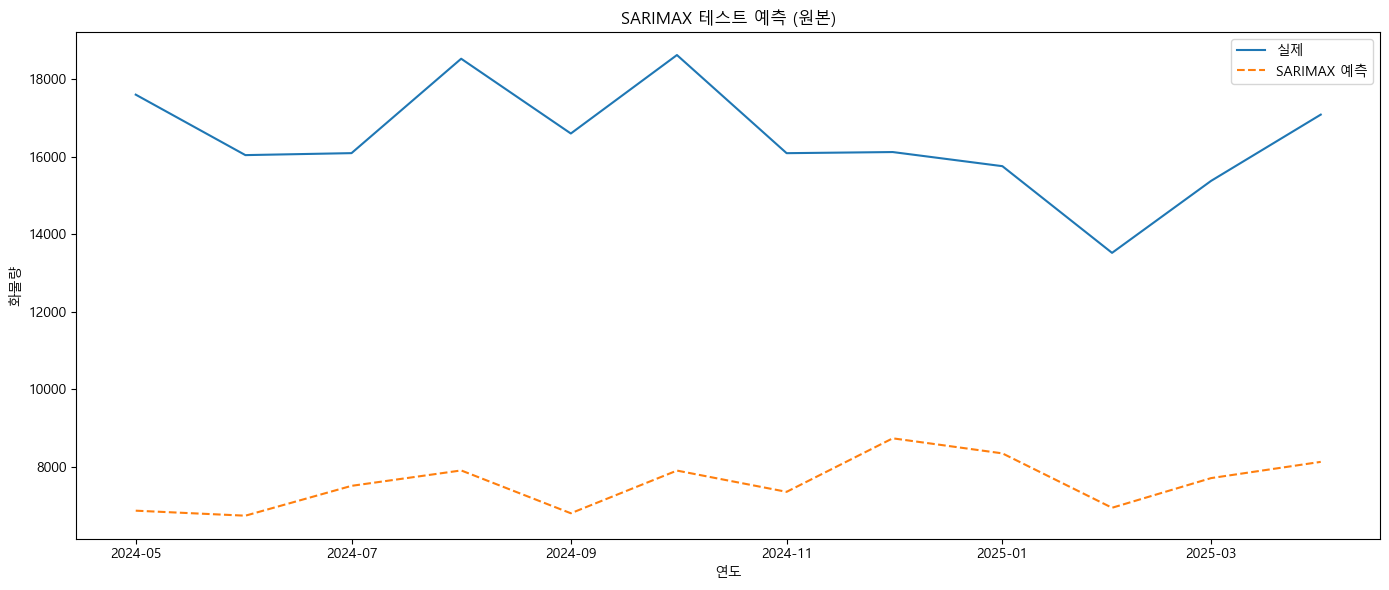

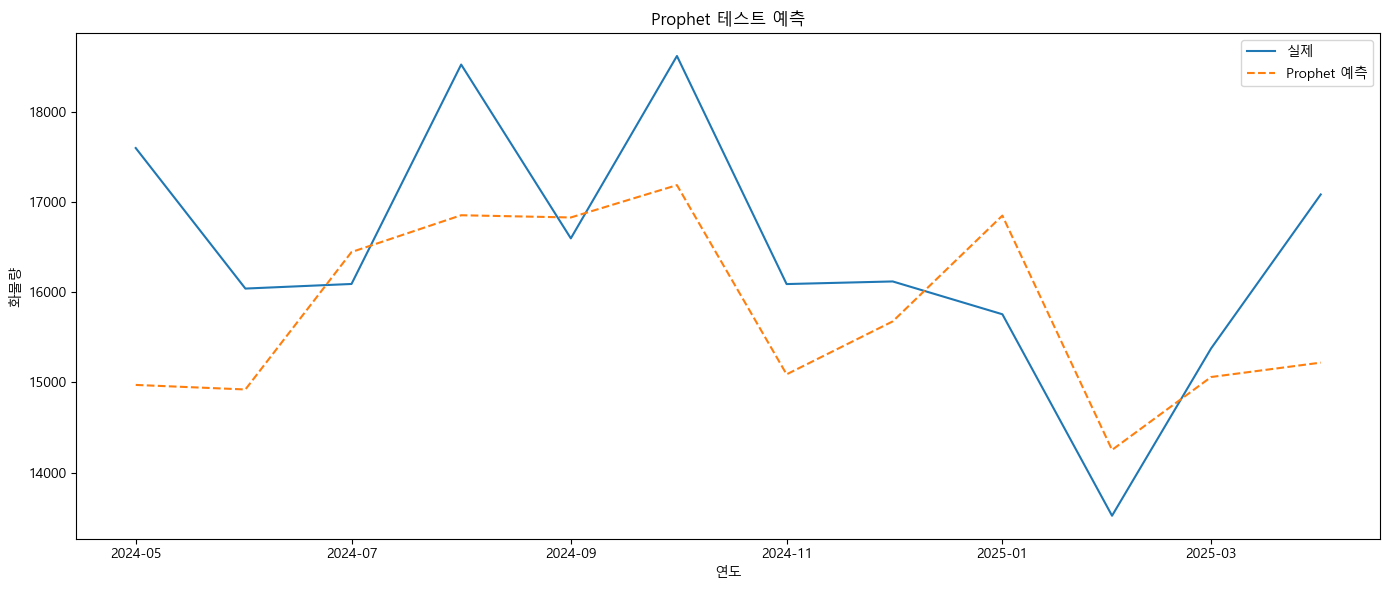

In [ ]:
import pandas as pd
import numpy as np
import itertools
import warnings
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from prophet import Prophet

# 한글 폰트
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
file_path = r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\data.xlsx"
df = pd.read_excel(file_path, sheet_name="데이터")
df["Date"] = pd.to_datetime(df[["year", "month"]].assign(DAY=1))
df.set_index("Date", inplace=True)

# 이상치 처리
y = df["airport"].astype(float).copy()
outlier_period = (y.index >= "2020-01-01") & (y.index <= "2021-12-31")
X = np.arange(len(y)).reshape(-1, 1)
X_no_outlier = X[~outlier_period]
y_no_outlier = y[~outlier_period]
model_lr = LinearRegression()
model_lr.fit(X_no_outlier, y_no_outlier)
y_pred_outlier = model_lr.predict(X[outlier_period])
y_corrected = y.copy()
y_corrected[outlier_period] = y_pred_outlier

# 끝에서 12개월 자동 분할
n_test = 12
y_train = y_corrected.iloc[:-n_test]
y_test = y_corrected.iloc[-n_test:]

exog_train = df["port"].iloc[:-n_test]
exog_test = df["port"].iloc[-n_test:]

# SARIMAX 훈련 데이터 차분
y_train_diff = y_train.diff().dropna()
exog_train_diff = exog_train.diff().dropna()

# SARIMAX 파라미터 탐색
p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))
aic_results = []
warnings.filterwarnings("ignore")

for param in pdq:
    try:
        model = SARIMAX(
            y_train_diff,
            exog=exog_train_diff,
            order=param,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        result = model.fit(disp=False)
        aic_results.append((param, result.aic))
    except:
        continue

aic_results.sort(key=lambda x: x[1])
best_param, best_aic = aic_results[0]
print(f"\n✅ SARIMAX 최적 파라미터: {best_param}")

# SARIMAX 학습
sarimax_model = SARIMAX(
    y_train_diff,
    exog=exog_train_diff,
    order=best_param,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# SARIMAX 예측 (원본)
n_forecast = len(y_test)
sarimax_forecast = sarimax_model.get_forecast(steps=n_forecast, exog=exog_test)
sarimax_pred = sarimax_forecast.predicted_mean

# 길이 검증 및 맞추기
assert len(y_test) == len(sarimax_pred), "예측값과 y_test 길이가 다릅니다."

# MAPE/RMSE 계산 (원본 기준)
mape_sarimax = mean_absolute_percentage_error(y_test, sarimax_pred)
rmse_sarimax = mean_squared_error(y_test, sarimax_pred, squared=False)

# Prophet 데이터 준비
prophet_df = pd.DataFrame({"ds": y_train.index, "y": y_train.values})
prophet_exog_train = exog_train.reset_index().rename(columns={"Date":"ds", "port":"exog"})

prophet_model = Prophet()
prophet_model.add_regressor("exog")

prophet_train_data = pd.merge(prophet_df, prophet_exog_train, on="ds")
prophet_model.fit(prophet_train_data)

# Prophet 테스트 데이터 준비
future = pd.DataFrame({"ds": y_test.index})
future_exog = exog_test.reset_index().rename(columns={"Date":"ds", "port":"exog"})
future_all = pd.merge(future, future_exog, on="ds")

prophet_pred = prophet_model.predict(future_all)

mape_prophet = mean_absolute_percentage_error(y_test, prophet_pred["yhat"])
rmse_prophet = mean_squared_error(y_test, prophet_pred["yhat"], squared=False)

# 결과 출력
print(f"\n✅ 테스트 구간(최근 12개월) 성능:")
print(f"SARIMAX MAPE={mape_sarimax:.4f}, RMSE={rmse_sarimax:.2f}")
print(f"Prophet MAPE={mape_prophet:.4f}, RMSE={rmse_prophet:.2f}")

# SARIMAX 예측 그래프
plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test, label="실제")
plt.plot(y_test.index, sarimax_pred, label="SARIMAX 예측", linestyle="--")
plt.title("SARIMAX 테스트 예측 (원본)")
plt.xlabel("연도")
plt.ylabel("화물량")
plt.legend()
plt.tight_layout()
plt.show()

# Prophet 예측 그래프
plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test, label="실제")
plt.plot(y_test.index, prophet_pred["yhat"], label="Prophet 예측", linestyle="--")
plt.title("Prophet 테스트 예측")
plt.xlabel("연도")
plt.ylabel("화물량")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import itertools
import warnings
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from prophet import Prophet

# 한글 폰트
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
file_path = r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\data.xlsx"
df = pd.read_excel(file_path, sheet_name="데이터")
df["Date"] = pd.to_datetime(df[["year", "month"]].assign(DAY=1))
df.set_index("Date", inplace=True)

# 이상치 처리
y = df["airport"].astype(float).copy()
outlier_period = (y.index >= "2020-01-01") & (y.index <= "2021-12-31")
X = np.arange(len(y)).reshape(-1, 1)
X_no_outlier = X[~outlier_period]
y_no_outlier = y[~outlier_period]
model_lr = LinearRegression()
model_lr.fit(X_no_outlier, y_no_outlier)
y_pred_outlier = model_lr.predict(X[outlier_period])
y_corrected = y.copy()
y_corrected[outlier_period] = y_pred_outlier

# 끝에서 12개월 자동 분할
n_test = 30
y_train = y_corrected.iloc[:-n_test]
y_test = y_corrected.iloc[-n_test:]

exog_train = df["port"].iloc[:-n_test]
exog_test = df["port"].iloc[-n_test:]

# SARIMAX 파라미터 탐색 (차분X)
p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))
aic_results = []
warnings.filterwarnings("ignore")

for param in pdq:
    try:
        model = SARIMAX(
            y_train,
            exog=exog_train,
            order=param,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        result = model.fit(disp=False)
        aic_results.append((param, result.aic))
    except:
        continue

aic_results.sort(key=lambda x: x[1])
best_param, best_aic = aic_results[0]
print(f"\n✅ SARIMAX(차분X) 최적 파라미터: {best_param}")

# SARIMAX 모델 학습
sarimax_model = SARIMAX(
    y_train,
    exog=exog_train,
    order=best_param,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# SARIMAX 예측
n_forecast = len(y_test)
sarimax_forecast = sarimax_model.get_forecast(steps=n_forecast, exog=exog_test)
sarimax_pred = sarimax_forecast.predicted_mean

# MAPE/RMSE 계산 (원본 기준)
mape_sarimax = mean_absolute_percentage_error(y_test, sarimax_pred)
rmse_sarimax = mean_squared_error(y_test, sarimax_pred, squared=False)

# Prophet 데이터 준비
prophet_df = pd.DataFrame({"ds": y_train.index, "y": y_train.values})
prophet_exog_train = exog_train.reset_index().rename(columns={"Date":"ds", "port":"exog"})

prophet_model = Prophet()
prophet_model.add_regressor("exog")

prophet_train_data = pd.merge(prophet_df, prophet_exog_train, on="ds")
prophet_model.fit(prophet_train_data)

# Prophet 테스트 데이터 준비
future = pd.DataFrame({"ds": y_test.index})
future_exog = exog_test.reset_index().rename(columns={"Date":"ds", "port":"exog"})
future_all = pd.merge(future, future_exog, on="ds")

prophet_pred = prophet_model.predict(future_all)

mape_prophet = mean_absolute_percentage_error(y_test, prophet_pred["yhat"])
rmse_prophet = mean_squared_error(y_test, prophet_pred["yhat"], squared=False)

# 결과 출력
print(f"\n✅ 테스트 구간(최근 12개월) 성능 (차분X):")
print(f"SARIMAX MAPE={mape_sarimax:.4f}, RMSE={rmse_sarimax:.2f}")
print(f"Prophet MAPE={mape_prophet:.4f}, RMSE={rmse_prophet:.2f}")

# SARIMAX 예측 그래프
plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test, label="실제")
plt.plot(y_test.index, sarimax_pred, label="SARIMAX 예측", linestyle="--")
plt.title("SARIMAX 테스트 예측 (차분X)")
plt.xlabel("연도")
plt.ylabel("화물량")
plt.legend()
plt.tight_layout()
plt.show()

# Prophet 예측 그래프
plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test, label="실제")
plt.plot(y_test.index, prophet_pred["yhat"], label="Prophet 예측", linestyle="--")
plt.title("Prophet 테스트 예측")
plt.xlabel("연도")
plt.ylabel("화물량")
plt.legend()
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\DAEJIN\\Desktop\\무역학회지 8월호\\data.xlsx'

In [ ]:
import pandas as pd
import numpy as np
import itertools
import warnings
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from prophet import Prophet

# 한글 폰트
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
file_path = r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\data.xlsx"
df = pd.read_excel(file_path, sheet_name="데이터")
df["Date"] = pd.to_datetime(df[["year", "month"]].assign(DAY=1))
df.set_index("Date", inplace=True)

# 이상치 처리
y = df["airport"].astype(float).copy()
outlier_period = (y.index >= "2020-01-01") & (y.index <= "2021-12-31")
X = np.arange(len(y)).reshape(-1, 1)
X_no_outlier = X[~outlier_period]
y_no_outlier = y[~outlier_period]
model_lr = LinearRegression()
model_lr.fit(X_no_outlier, y_no_outlier)
y_pred_outlier = model_lr.predict(X[outlier_period])
y_corrected = y.copy()
y_corrected[outlier_period] = y_pred_outlier

# 끝에서 12개월 자동 분할
n_test = 6
y_train = y_corrected.iloc[:-n_test]
y_test = y_corrected.iloc[-n_test:]

exog_train = df["port"].iloc[:-n_test]
exog_test = df["port"].iloc[-n_test:]

# SARIMAX 파라미터 탐색 (외생변수 포함)
p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))
aic_results_exog = []
warnings.filterwarnings("ignore")

for param in pdq:
    try:
        model = SARIMAX(
            y_train,
            exog=exog_train,
            order=param,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        result = model.fit(disp=False)
        aic_results_exog.append((param, result.aic))
    except:
        continue

aic_results_exog.sort(key=lambda x: x[1])
best_param_exog, _ = aic_results_exog[0]

# SARIMAX 파라미터 탐색 (외생변수 없음)
aic_results_noexog = []
for param in pdq:
    try:
        model = SARIMAX(
            y_train,
            order=param,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        result = model.fit(disp=False)
        aic_results_noexog.append((param, result.aic))
    except:
        continue

aic_results_noexog.sort(key=lambda x: x[1])
best_param_noexog, _ = aic_results_noexog[0]

print(f"\n✅ SARIMAX(외생변수) 최적 파라미터: {best_param_exog}")
print(f"✅ SARIMAX(무) 최적 파라미터: {best_param_noexog}")

# SARIMAX 모델 학습 (외생변수 포함)
sarimax_model_exog = SARIMAX(
    y_train,
    exog=exog_train,
    order=best_param_exog,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# SARIMAX 모델 학습 (외생변수 없음)
sarimax_model_noexog = SARIMAX(
    y_train,
    order=best_param_noexog,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# SARIMAX 예측
sarimax_pred_exog = sarimax_model_exog.get_forecast(steps=n_test, exog=exog_test).predicted_mean
sarimax_pred_noexog = sarimax_model_noexog.get_forecast(steps=n_test).predicted_mean

# MAPE/RMSE 계산
mape_sarimax_exog = mean_absolute_percentage_error(y_test, sarimax_pred_exog)
rmse_sarimax_exog = mean_squared_error(y_test, sarimax_pred_exog, squared=False)

mape_sarimax_noexog = mean_absolute_percentage_error(y_test, sarimax_pred_noexog)
rmse_sarimax_noexog = mean_squared_error(y_test, sarimax_pred_noexog, squared=False)

# Prophet 데이터 준비
prophet_df = pd.DataFrame({"ds": y_train.index, "y": y_train.values})
prophet_exog_train = exog_train.reset_index().rename(columns={"Date":"ds", "port":"exog"})

# Prophet(외생변수 포함)
prophet_model_exog = Prophet()
prophet_model_exog.add_regressor("exog")
prophet_train_data = pd.merge(prophet_df, prophet_exog_train, on="ds")
prophet_model_exog.fit(prophet_train_data)

future = pd.DataFrame({"ds": y_test.index})
future_exog = exog_test.reset_index().rename(columns={"Date":"ds", "port":"exog"})
future_all = pd.merge(future, future_exog, on="ds")

prophet_pred_exog = prophet_model_exog.predict(future_all)

mape_prophet_exog = mean_absolute_percentage_error(y_test, prophet_pred_exog["yhat"])
rmse_prophet_exog = mean_squared_error(y_test, prophet_pred_exog["yhat"], squared=False)

# Prophet(외생변수 없음)
prophet_model_noexog = Prophet()
prophet_model_noexog.fit(prophet_df)

prophet_pred_noexog = prophet_model_noexog.predict(future)

mape_prophet_noexog = mean_absolute_percentage_error(y_test, prophet_pred_noexog["yhat"])
rmse_prophet_noexog = mean_squared_error(y_test, prophet_pred_noexog["yhat"], squared=False)

# 결과 출력
print("\n✅ 테스트 구간(최근 12개월) 성능 비교:")
print(f"SARIMAX(외생)   MAPE={mape_sarimax_exog:.4f}, RMSE={rmse_sarimax_exog:.2f}")
print(f"SARIMAX(무)     MAPE={mape_sarimax_noexog:.4f}, RMSE={rmse_sarimax_noexog:.2f}")
print(f"Prophet(외생)   MAPE={mape_prophet_exog:.4f}, RMSE={rmse_prophet_exog:.2f}")
print(f"Prophet(무)     MAPE={mape_prophet_noexog:.4f}, RMSE={rmse_prophet_noexog:.2f}")

# 그래프
plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test, label="실제")
plt.plot(y_test.index, sarimax_pred_exog, label="SARIMAX(외생)", linestyle="--")
plt.plot(y_test.index, sarimax_pred_noexog, label="SARIMAX(무)", linestyle=":")
plt.title("SARIMAX 테스트 예측 (차분X)")
plt.xlabel("연도")
plt.ylabel("화물량")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test, label="실제")
plt.plot(y_test.index, prophet_pred_exog["yhat"], label="Prophet(외생)", linestyle="--")
plt.plot(y_test.index, prophet_pred_noexog["yhat"], label="Prophet(무)", linestyle=":")
plt.title("Prophet 테스트 예측")
plt.xlabel("연도")
plt.ylabel("화물량")
plt.legend()
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\DAEJIN\\Desktop\\무역학회지 8월호\\data.xlsx'

19:13:29 - cmdstanpy - INFO - Chain [1] start processing
19:13:29 - cmdstanpy - INFO - Chain [1] done processing
19:13:29 - cmdstanpy - INFO - Chain [1] start processing
19:13:29 - cmdstanpy - INFO - Chain [1] done processing



✅ 테스트 구간(최근 12개월) 성능 비교:
SARIMAX(외생)     MAPE=0.1368, RMSE=2559.42
SARIMAX(무)       MAPE=0.1364, RMSE=2552.76
Prophet(외생)     MAPE=0.0638, RMSE=1281.14
Prophet(무)       MAPE=0.0678, RMSE=1385.50


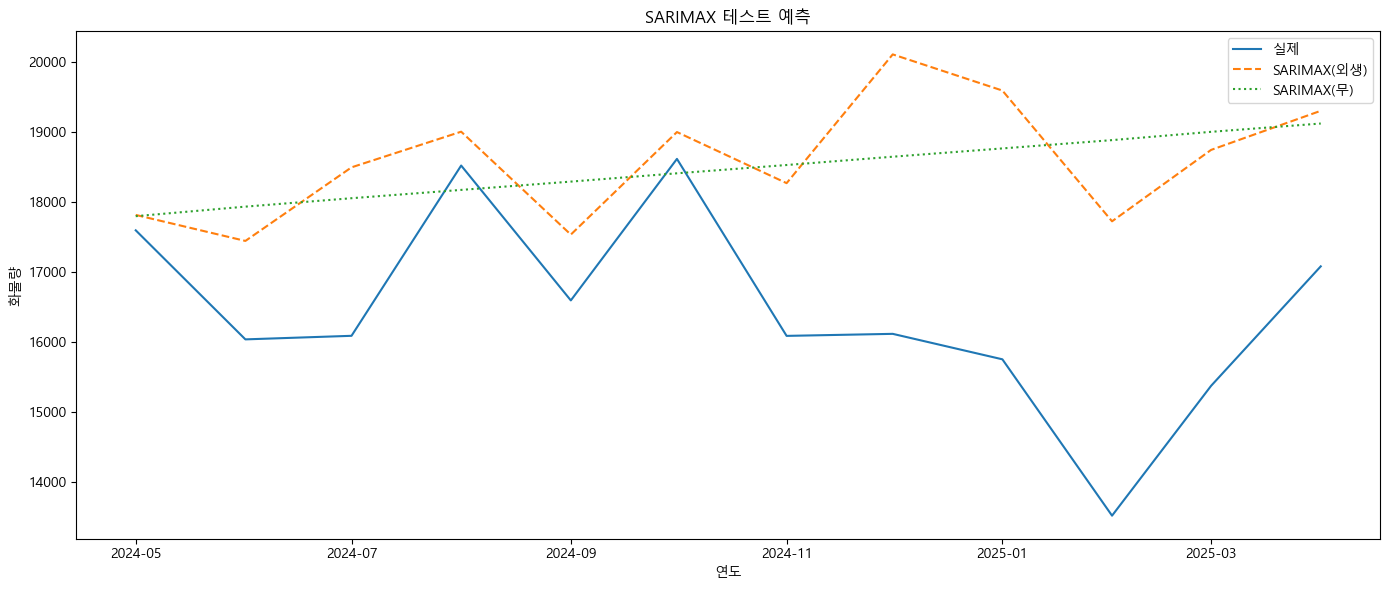

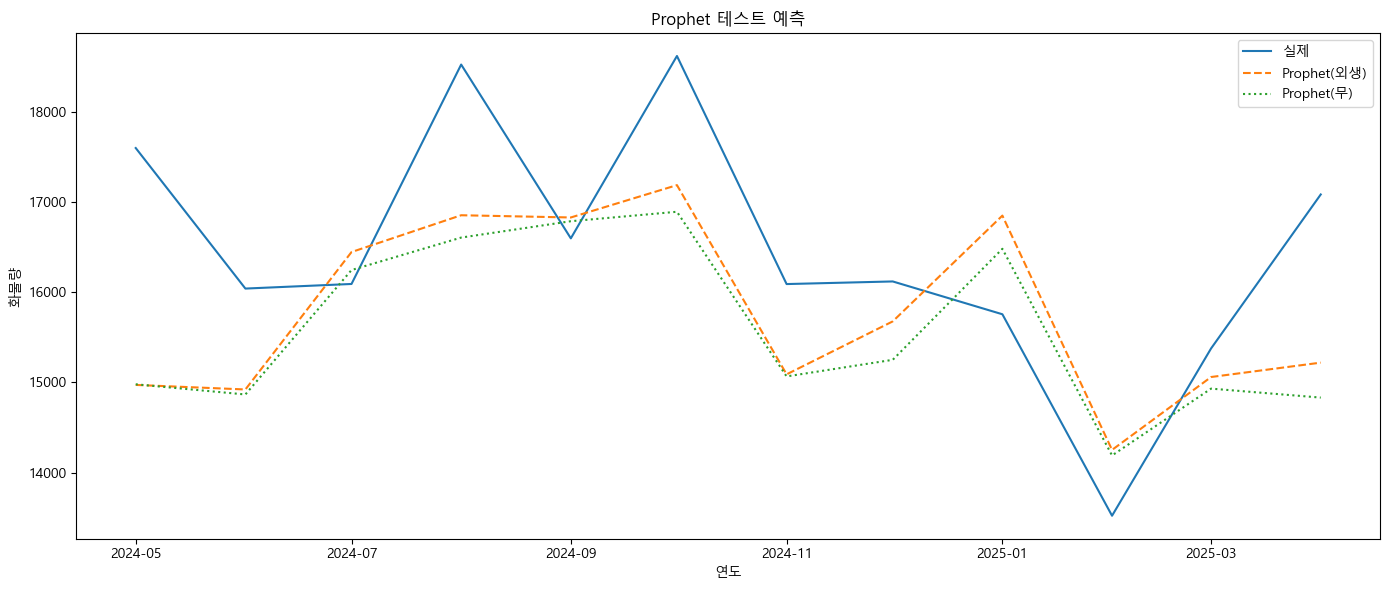

In [ ]:
import pandas as pd
import numpy as np
import itertools
import warnings
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from prophet import Prophet

# 한글 폰트
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
file_path = r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\data.xlsx"
df = pd.read_excel(file_path, sheet_name="데이터")
df["Date"] = pd.to_datetime(df[["year", "month"]].assign(DAY=1))
df.set_index("Date", inplace=True)

# 이상치 처리
y = df["airport"].astype(float).copy()
outlier_period = (y.index >= "2020-01-01") & (y.index <= "2021-12-31")
X = np.arange(len(y)).reshape(-1, 1)
X_no_outlier = X[~outlier_period]
y_no_outlier = y[~outlier_period]
model_lr = LinearRegression()
model_lr.fit(X_no_outlier, y_no_outlier)
y_pred_outlier = model_lr.predict(X[outlier_period])
y_corrected = y.copy()
y_corrected[outlier_period] = y_pred_outlier

# 끝에서 12개월 자동 분할
n_test = 12
y_train = y_corrected.iloc[:-n_test]
y_test = y_corrected.iloc[-n_test:]

exog_train = df["port"].iloc[:-n_test]
exog_test = df["port"].iloc[-n_test:]

# SARIMAX 파라미터 탐색 함수
def find_best_sarimax(y_train, exog_train=None):
    p = d = q = range(0, 3)
    pdq = list(itertools.product(p, d, q))
    aic_results = []
    for param in pdq:
        try:
            model = SARIMAX(
                y_train,
                exog=exog_train,
                order=param,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            result = model.fit(disp=False)
            aic_results.append((param, result.aic))
        except:
            continue
    aic_results.sort(key=lambda x: x[1])
    return aic_results[0][0]

# SARIMAX(외생)
best_param_exog = find_best_sarimax(y_train, exog_train)
model_exog = SARIMAX(y_train, exog=exog_train, order=best_param_exog).fit(disp=False)
pred_exog = model_exog.get_forecast(steps=n_test, exog=exog_test).predicted_mean
mape_exog = mean_absolute_percentage_error(y_test, pred_exog)
rmse_exog = mean_squared_error(y_test, pred_exog, squared=False)

# SARIMAX(무)
best_param_noexog = find_best_sarimax(y_train, None)
model_noexog = SARIMAX(y_train, order=best_param_noexog).fit(disp=False)
pred_noexog = model_noexog.get_forecast(steps=n_test).predicted_mean
mape_noexog = mean_absolute_percentage_error(y_test, pred_noexog)
rmse_noexog = mean_squared_error(y_test, pred_noexog, squared=False)

# Prophet(외생)
prophet_df = pd.DataFrame({"ds": y_train.index, "y": y_train.values})
prophet_exog_train = exog_train.reset_index().rename(columns={"Date":"ds","port":"exog"})
prophet_model_exog = Prophet()
prophet_model_exog.add_regressor("exog")
train_exog_data = pd.merge(prophet_df, prophet_exog_train, on="ds")
prophet_model_exog.fit(train_exog_data)
future = pd.DataFrame({"ds": y_test.index})
future_exog = exog_test.reset_index().rename(columns={"Date":"ds","port":"exog"})
future_all = pd.merge(future, future_exog, on="ds")
prophet_pred_exog = prophet_model_exog.predict(future_all)
mape_prophet_exog = mean_absolute_percentage_error(y_test, prophet_pred_exog["yhat"])
rmse_prophet_exog = mean_squared_error(y_test, prophet_pred_exog["yhat"], squared=False)

# Prophet(무)
prophet_model_noexog = Prophet()
prophet_model_noexog.fit(prophet_df)
prophet_pred_noexog = prophet_model_noexog.predict(future)
mape_prophet_noexog = mean_absolute_percentage_error(y_test, prophet_pred_noexog["yhat"])
rmse_prophet_noexog = mean_squared_error(y_test, prophet_pred_noexog["yhat"], squared=False)

# 예측
future_exog_lag1 = exog_test_lag1.reset_index().rename(columns={"Date":"ds","port":"exog"})
future_all_lag1 = pd.merge(future, future_exog_lag1, on="ds")
prophet_pred_lag1 = prophet_model_lag1.predict(future_all_lag1)

# MAPE/RMSE 계산
mape_prophet_lag1 = mean_absolute_percentage_error(y_test, prophet_pred_lag1["yhat"])
rmse_prophet_lag1 = mean_squared_error(y_test, prophet_pred_lag1["yhat"], squared=False)

# 결과 출력
print("\n✅ 테스트 구간(최근 12개월) 성능 비교:")
print(f"SARIMAX(외생)     MAPE={mape_exog:.4f}, RMSE={rmse_exog:.2f}")
print(f"SARIMAX(무)       MAPE={mape_noexog:.4f}, RMSE={rmse_noexog:.2f}")
print(f"Prophet(외생)     MAPE={mape_prophet_exog:.4f}, RMSE={rmse_prophet_exog:.2f}")
print(f"Prophet(무)       MAPE={mape_prophet_noexog:.4f}, RMSE={rmse_prophet_noexog:.2f}")

# 그래프
plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test, label="실제")
plt.plot(y_test.index, pred_exog, label="SARIMAX(외생)", linestyle="--")
plt.plot(y_test.index, pred_noexog, label="SARIMAX(무)", linestyle=":")

plt.title("SARIMAX 테스트 예측")
plt.xlabel("연도")
plt.ylabel("화물량")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test, label="실제")
plt.plot(y_test.index, prophet_pred_exog["yhat"], label="Prophet(외생)", linestyle="--")
plt.plot(y_test.index, prophet_pred_noexog["yhat"], label="Prophet(무)", linestyle=":")

plt.title("Prophet 테스트 예측")
plt.xlabel("연도")
plt.ylabel("화물량")
plt.legend()
plt.tight_layout()
plt.show()


✅ SARIMAX(외생) 최적 파라미터: (1, 2, 2)
✅ SARIMAX(무)   최적 파라미터: (1, 2, 2)


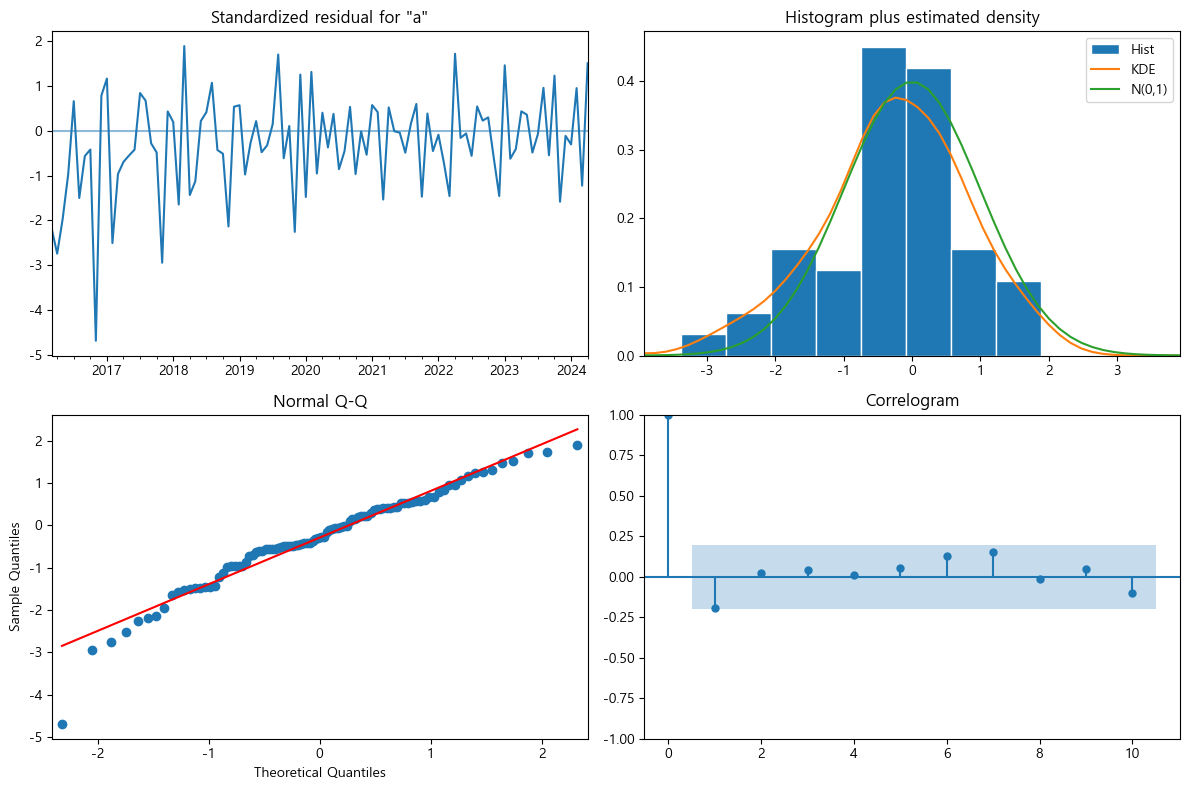

In [ ]:
# SARIMAX(외생) 모델 진단 그래프
model_exog.plot_diagnostics(figsize=(12,8))
plt.tight_layout()
plt.show()

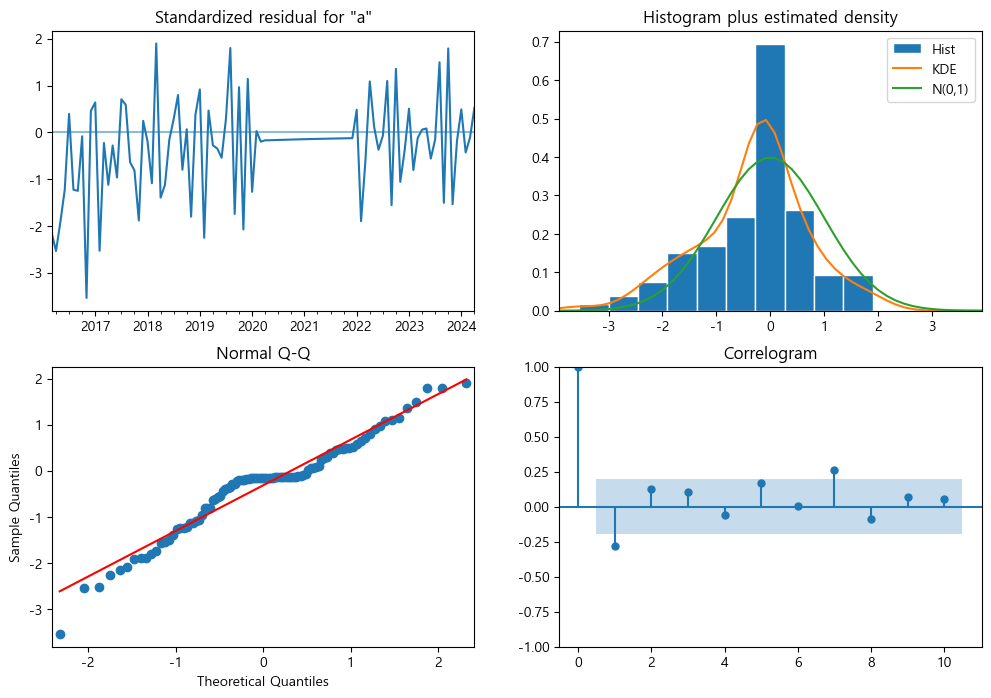

In [ ]:
model_noexog.plot_diagnostics(figsize=(12,8));

16:49:01 - cmdstanpy - INFO - Chain [1] start processing
16:49:01 - cmdstanpy - INFO - Chain [1] done processing
16:49:01 - cmdstanpy - INFO - Chain [1] start processing
16:49:01 - cmdstanpy - INFO - Chain [1] done processing



✅ 테스트 구간(최근 12개월) 성능 비교:
SARIMAX(외생)   MAPE=0.1368, RMSE=2559.42
SARIMAX(무)     MAPE=0.1364, RMSE=2552.76
Prophet(외생)   MAPE=0.0638, RMSE=1281.14
Prophet(무)     MAPE=0.0678, RMSE=1385.50


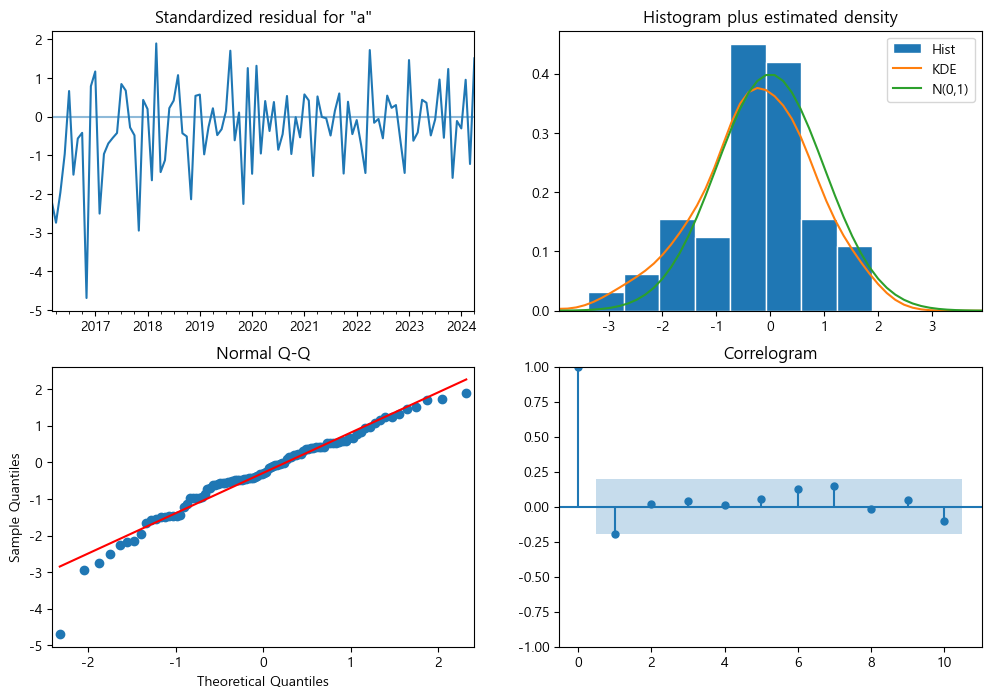

In [ ]:
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from prophet import Prophet
import warnings
warnings.filterwarnings("ignore")

# 한글 폰트
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
file_path = r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\data.xlsx"
df = pd.read_excel(file_path, sheet_name="데이터")
df["Date"] = pd.to_datetime(df[["year", "month"]].assign(DAY=1))
df.set_index("Date", inplace=True)

# 이상치 보정
y = df["airport"].astype(float).copy()
outlier_period = (y.index >= "2020-01-01") & (y.index <= "2021-12-31")
X = np.arange(len(y)).reshape(-1, 1)
X_no_outlier = X[~outlier_period]
y_no_outlier = y[~outlier_period]
model_lr = LinearRegression()
model_lr.fit(X_no_outlier, y_no_outlier)
y_pred_outlier = model_lr.predict(X[outlier_period])
y_corrected = y.copy()
y_corrected[outlier_period] = y_pred_outlier

# 학습/테스트셋
n_test = 12
y_train = y_corrected.iloc[:-n_test]
y_test = y_corrected.iloc[-n_test:]
exog_train = df["port"].iloc[:-n_test]
exog_test = df["port"].iloc[-n_test:]

# SARIMAX 파라미터 탐색
def find_best_sarimax(y_train, exog_train=None):
    p = d = q = range(0, 3)
    pdq = list(itertools.product(p, d, q))
    aic_results = []
    for param in pdq:
        try:
            model = SARIMAX(
                y_train,
                exog=exog_train,
                order=param,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            result = model.fit(disp=False)
            aic_results.append((param, result.aic))
        except:
            continue
    aic_results.sort(key=lambda x: x[1])
    return aic_results[0][0]

# SARIMAX(외생)
best_param_exog = find_best_sarimax(y_train, exog_train)
model_exog = SARIMAX(y_train, exog=exog_train, order=best_param_exog).fit(disp=False)
pred_exog = model_exog.get_forecast(steps=n_test, exog=exog_test).predicted_mean
mape_exog = mean_absolute_percentage_error(y_test, pred_exog)
rmse_exog = mean_squared_error(y_test, pred_exog, squared=False)

# SARIMAX(무)
best_param_noexog = find_best_sarimax(y_train)
model_noexog = SARIMAX(y_train, order=best_param_noexog).fit(disp=False)
pred_noexog = model_noexog.get_forecast(steps=n_test).predicted_mean
mape_noexog = mean_absolute_percentage_error(y_test, pred_noexog)
rmse_noexog = mean_squared_error(y_test, pred_noexog, squared=False)

# Prophet(외생)
prophet_df = pd.DataFrame({"ds": y_train.index, "y": y_train.values})
prophet_exog_train = exog_train.reset_index().rename(columns={"Date":"ds","port":"exog"})
prophet_model_exog = Prophet()
prophet_model_exog.add_regressor("exog")
train_exog_data = pd.merge(prophet_df, prophet_exog_train, on="ds")
prophet_model_exog.fit(train_exog_data)
future = pd.DataFrame({"ds": y_test.index})
future_exog = exog_test.reset_index().rename(columns={"Date":"ds","port":"exog"})
future_all = pd.merge(future, future_exog, on="ds")
prophet_pred_exog = prophet_model_exog.predict(future_all)
mape_prophet_exog = mean_absolute_percentage_error(y_test, prophet_pred_exog["yhat"])
rmse_prophet_exog = mean_squared_error(y_test, prophet_pred_exog["yhat"], squared=False)

# Prophet(무)
prophet_model_noexog = Prophet()
prophet_model_noexog.fit(prophet_df)
prophet_pred_noexog = prophet_model_noexog.predict(future)
mape_prophet_noexog = mean_absolute_percentage_error(y_test, prophet_pred_noexog["yhat"])
rmse_prophet_noexog = mean_squared_error(y_test, prophet_pred_noexog["yhat"], squared=False)

# 결과 출력
print("\n✅ 테스트 구간(최근 12개월) 성능 비교:")
print(f"SARIMAX(외생)   MAPE={mape_exog:.4f}, RMSE={rmse_exog:.2f}")
print(f"SARIMAX(무)     MAPE={mape_noexog:.4f}, RMSE={rmse_noexog:.2f}")
print(f"Prophet(외생)   MAPE={mape_prophet_exog:.4f}, RMSE={rmse_prophet_exog:.2f}")
print(f"Prophet(무)     MAPE={mape_prophet_noexog:.4f}, RMSE={rmse_prophet_noexog:.2f}")

# SARIMAX 진단 그래프
model_exog.plot_diagnostics(figsize=(12,8));


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


           ds          yhat    yhat_lower    yhat_upper
0  2025-06-01  14984.146164  13867.246406  16023.223927
1  2025-07-01  15557.722830  14527.055583  16602.329405
2  2025-08-01  16925.633994  15846.332820  17951.851995
3  2025-09-01  16373.935705  15346.685001  17480.812220
4  2025-10-01  17068.645095  16000.454387  18038.743435
5  2025-11-01  15079.503267  13856.984113  16200.174693
6  2025-12-01  15124.539502  14050.371174  16260.317513
7  2026-01-01  15789.855641  14773.777199  16875.465592
8  2026-02-01  14458.403676  13420.008709  15582.429228
9  2026-03-01  14627.692214  13628.547788  15721.261994
10 2026-04-01  14940.511907  13853.623801  15973.804068
11 2026-05-01  14880.267016  13760.695650  15880.325582
12 2026-06-01  14241.677440  13228.551171  15301.519894
13 2026-07-01  14607.874239  13422.897391  15655.648910
14 2026-08-01  16357.319344  15294.579247  17382.542632
15 2026-09-01  15462.080220  14410.142779  16496.820842
16 2026-10-01  16309.957452  15322.035716  17381

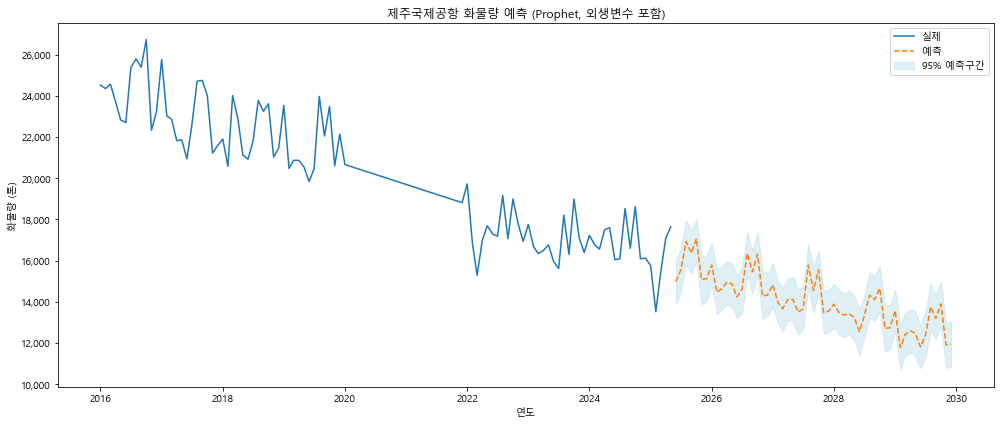

In [ ]:
from prophet import Prophet
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 데이터 불러오기
file_path = r"C:\Users\vpsxl\Desktop\무역학회지 8월호\data.xlsx"
df = pd.read_excel(file_path, sheet_name="데이터")
df["Date"] = pd.to_datetime(df[["year", "month"]].assign(DAY=1))
df.set_index("Date", inplace=True)

# 이상치 보정
y = df["airport"].astype(float).copy()
outlier_period = (y.index >= "2020-01-01") & (y.index <= "2021-12-31")
X = np.arange(len(y)).reshape(-1, 1)
X_no_outlier = X[~outlier_period]
y_no_outlier = y[~outlier_period]
model_lr = LinearRegression()
model_lr.fit(X_no_outlier, y_no_outlier)
y_pred_outlier = model_lr.predict(X[outlier_period])
y_corrected = y.copy()
y_corrected[outlier_period] = y_pred_outlier

# 전체 데이터 학습
y_train = y_corrected
exog_train = df["port"]

# Prophet 모델 선언
prophet_df = pd.DataFrame({
    "ds": y_train.index,
    "y": y_train.values
})
exog_train_df = exog_train.reset_index().rename(columns={"Date": "ds", "port": "exog"})

m = Prophet()
m.add_regressor("exog")

# 학습 데이터 merge
train_all = pd.merge(prophet_df, exog_train_df, on="ds")
m.fit(train_all)

# 미래 날짜 생성 (2029년 12월까지)
future_dates = pd.date_range(
    start=y_train.index[-1] + pd.offsets.MonthBegin(),
    end="2029-12-01",
    freq="MS"
)
future = pd.DataFrame({"ds": future_dates})

# 외생변수 미래 값 (단순히 마지막 값으로 고정)
last_exog_value = exog_train.iloc[-1]
future["exog"] = last_exog_value

# 예측
forecast = m.predict(future)

# 결과 DataFrame
result_df = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]]
print(result_df)

# 예측 데이터 Excel 저장
result_df.to_excel(r"C:\Users\vpsxl\Desktop\무역학회지 8월호\제주공항_화물량_예측결과.xlsx", index=False)

# 그래프 저장
plt.figure(figsize=(14,6))
plt.plot(y_train.index, y_train, label="실제")
plt.plot(result_df["ds"], result_df["yhat"], label="예측", linestyle="--")
plt.fill_between(
    result_df["ds"],
    result_df["yhat_lower"],
    result_df["yhat_upper"],
    color="lightblue",
    alpha=0.4,
    label="95% 예측구간"
)

plt.title("제주국제공항 화물량 예측 (Prophet, 외생변수 포함)")
plt.xlabel("연도")
plt.ylabel("화물량 (톤)")

# Y축 천단위 콤마
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format(int(x), ",")))

plt.legend()
plt.tight_layout()

# 그림 파일 저장
plt.savefig(r"C:\Users\vpsxl\Desktop\무역학회지 8월호\제주공항_화물량_예측그래프.png", dpi=300)

# 화면에 표시
plt.show()


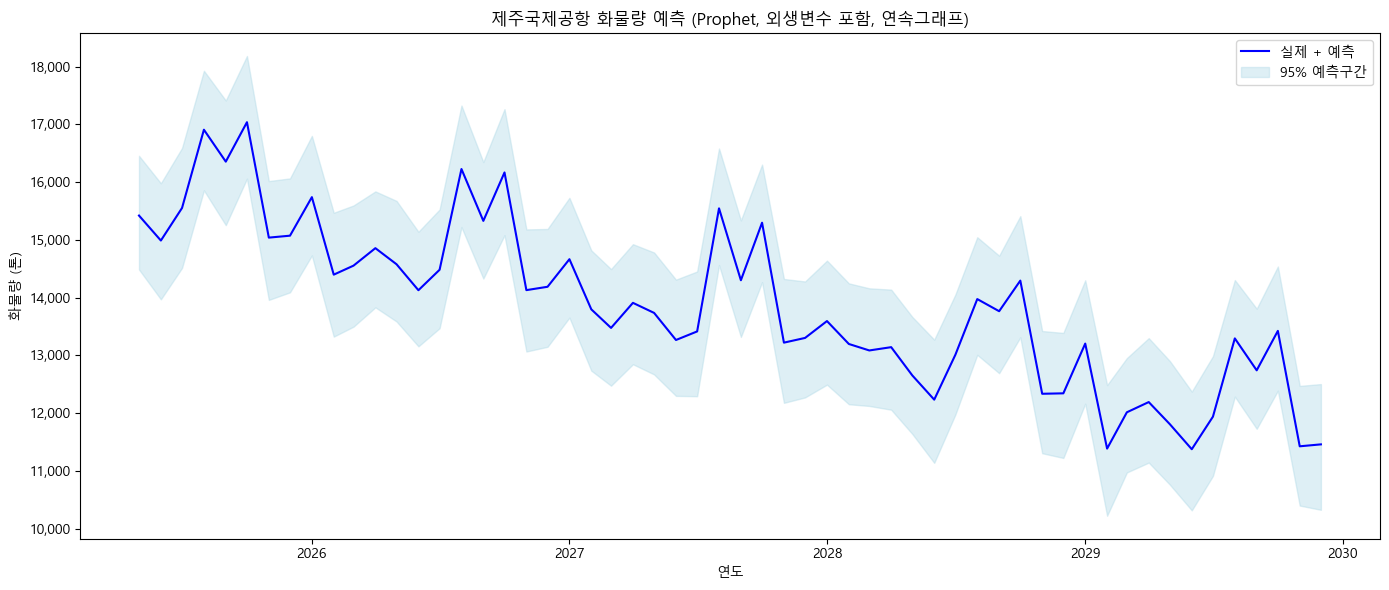

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 실제 + 예측 모두 하나의 DataFrame으로
concat_df = pd.concat([
    pd.DataFrame({"ds": y_train.index, "yhat": y_train}),
    result_df.rename(columns={"yhat": "y"})
], ignore_index=True)

# 그래프
plt.figure(figsize=(14,6))
plt.plot(concat_df["ds"], concat_df["y"], label="실제 + 예측", color="blue")
plt.fill_between(
    result_df["ds"],
    result_df["yhat_lower"],
    result_df["yhat_upper"],
    color="lightblue",
    alpha=0.4,
    label="95% 예측구간"
)

plt.title("제주국제공항 화물량 예측 (Prophet, 외생변수 포함, 연속그래프)")
plt.xlabel("연도")
plt.ylabel("화물량 (톤)")

# Y축 천단위 콤마
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format(int(x), ",")))

# 그림 파일 저장
plt.savefig(r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\제주공항_화물량_세부 예측그래프.png", dpi=300)

plt.legend()
plt.tight_layout()
plt.show()

시나리오 A: 제주항 물동량이 그대로 유지된다.

시나리오 B: 제주항 물동량이 10% 증가한다.

시나리오 C: 제주항 물동량이 20% 감소한다.

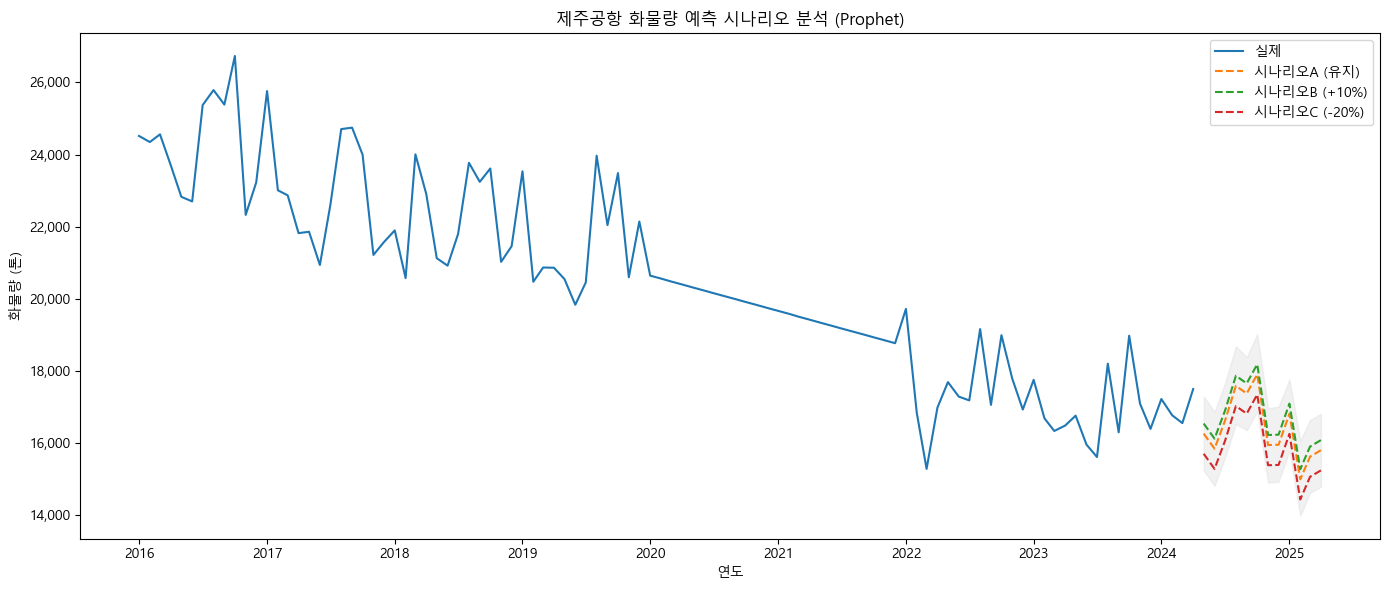

In [ ]:
# 시나리오 A: 현 상태 유지
scenario_A = future.copy()
scenario_A["exog"] = last_exog_value

# 시나리오 B: 10% 증가
scenario_B = future.copy()
scenario_B["exog"] = last_exog_value * 1.10

# 시나리오 C: 20% 감소
scenario_C = future.copy()
scenario_C["exog"] = last_exog_value * 0.80

# 각각 예측
forecast_A = m.predict(scenario_A)
forecast_B = m.predict(scenario_B)
forecast_C = m.predict(scenario_C)

# 그래프 비교
plt.figure(figsize=(14,6))
plt.plot(y_train.index, y_train, label="실제")

plt.plot(forecast_A["ds"], forecast_A["yhat"], label="시나리오A (유지)", linestyle="--")
plt.plot(forecast_B["ds"], forecast_B["yhat"], label="시나리오B (+10%)", linestyle="--")
plt.plot(forecast_C["ds"], forecast_C["yhat"], label="시나리오C (-20%)", linestyle="--")

plt.fill_between(
    forecast_A["ds"],
    forecast_A["yhat_lower"],
    forecast_A["yhat_upper"],
    color="lightgray",
    alpha=0.3
)

plt.title("제주공항 화물량 예측 시나리오 분석 (Prophet)")
plt.xlabel("연도")
plt.ylabel("화물량 (톤)")

# Y축 천단위 콤마
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format(int(x), ",")))

plt.legend()
plt.tight_layout()
plt.show()


19:35:33 - cmdstanpy - INFO - Chain [1] start processing
19:35:33 - cmdstanpy - INFO - Chain [1] done processing
19:35:33 - cmdstanpy - INFO - Chain [1] start processing
19:35:33 - cmdstanpy - INFO - Chain [1] done processing


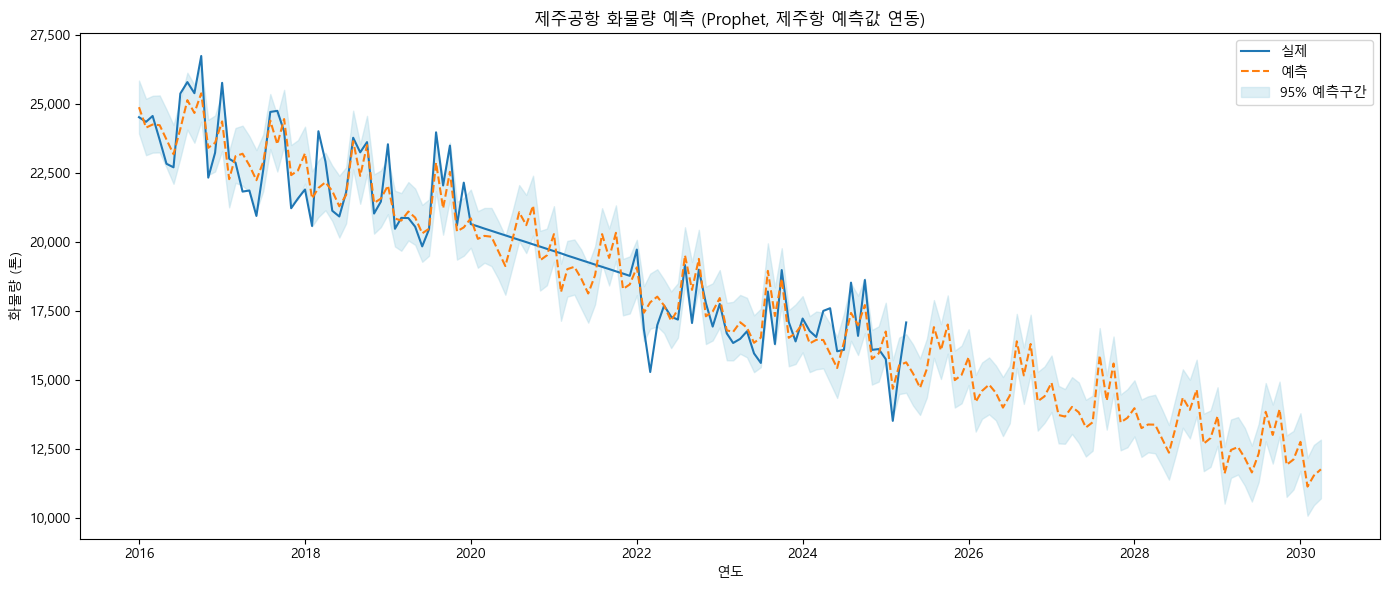

In [ ]:
from prophet import Prophet
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. 데이터 불러오기
file_path = r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\data.xlsx"
df = pd.read_excel(file_path, sheet_name="데이터")
df["Date"] = pd.to_datetime(df[["year", "month"]].assign(DAY=1))
df.set_index("Date", inplace=True)

# 2. 제주공항 이상치 보정
y = df["airport"].astype(float).copy()
outlier_period = (y.index >= "2020-01-01") & (y.index <= "2021-12-31")
X = np.arange(len(y)).reshape(-1, 1)
X_no_outlier = X[~outlier_period]
y_no_outlier = y[~outlier_period]
model_lr = LinearRegression()
model_lr.fit(X_no_outlier, y_no_outlier)
y_pred_outlier = model_lr.predict(X[outlier_period])
y_corrected = y.copy()
y_corrected[outlier_period] = y_pred_outlier

# 3. 제주항 데이터 Prophet 학습
port_df = pd.DataFrame({
    "ds": df.index,
    "y": df["port"].values
})

port_model = Prophet()
port_model.fit(port_df)

# 4. 제주항 미래 데이터 생성
future_port = port_model.make_future_dataframe(periods=60, freq="MS")
forecast_port = port_model.predict(future_port)

# 5. 제주항 예측값 가져오기
future_port_values = forecast_port[["ds", "yhat"]].copy()
future_port_values = future_port_values.rename(columns={"yhat": "exog"})

# 6. 제주공항 데이터 준비
airport_df = pd.DataFrame({
    "ds": df.index,
    "y": y_corrected.values
})

# 7. Prophet 모델 선언 및 외생변수 추가
m = Prophet()
m.add_regressor("exog")

# 8. 과거 데이터 merge
past_exog = df["port"].reset_index().rename(columns={"Date": "ds", "port": "exog"})
train_data = pd.merge(airport_df, past_exog, on="ds")

# 9. 모델 학습
m.fit(train_data)

# 10. 예측용 데이터 준비 (제주항 예측결과 사용)
future_all = future_port_values.copy()

# 11. 제주공항 예측 수행
forecast_airport = m.predict(future_all)

# 12. 결과 저장
result_df = forecast_airport[["ds", "yhat", "yhat_lower", "yhat_upper"]]
result_df.to_excel(r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\제주공항_예측_제주항예측연동.xlsx", index=False)

# 13. 그래프 시각화
plt.figure(figsize=(14,6))
plt.plot(train_data["ds"], train_data["y"], label="실제")
plt.plot(result_df["ds"], result_df["yhat"], label="예측", linestyle="--")
plt.fill_between(
    result_df["ds"],
    result_df["yhat_lower"],
    result_df["yhat_upper"],
    color="lightblue",
    alpha=0.4,
    label="95% 예측구간"
)

plt.title("제주공항 화물량 예측 (Prophet, 제주항 예측값 연동)")
plt.xlabel("연도")
plt.ylabel("화물량 (톤)")

# Y축 천단위 콤마
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format(int(x), ",")))

plt.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\제주공항_예측_제주항연동그래프.png", dpi=300)
plt.show()



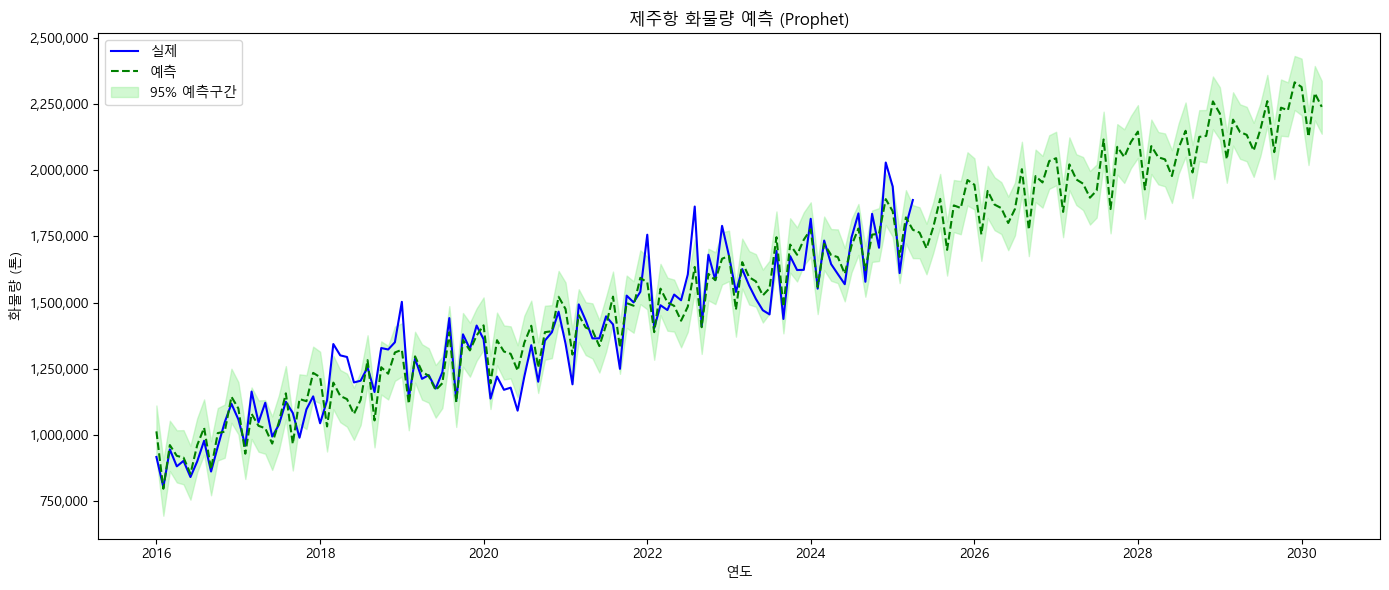

In [ ]:
# 제주항 예측결과 DataFrame
port_result_df = forecast_port[["ds", "yhat", "yhat_lower", "yhat_upper"]]
port_result_df.to_excel(r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\제주항_화물량_예측결과.xlsx", index=False)

# 그래프 시각화
plt.figure(figsize=(14,6))

# 과거 실제값
plt.plot(port_df["ds"], port_df["y"], label="실제", color="blue")

# 예측값
plt.plot(port_result_df["ds"], port_result_df["yhat"], label="예측", linestyle="--", color="green")

# 예측 구간
plt.fill_between(
    port_result_df["ds"],
    port_result_df["yhat_lower"],
    port_result_df["yhat_upper"],
    color="lightgreen",
    alpha=0.4,
    label="95% 예측구간"
)

plt.title("제주항 화물량 예측 (Prophet)")
plt.xlabel("연도")
plt.ylabel("화물량 (톤)")

# Y축 천단위 콤마
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format(int(x), ",")))

plt.legend()
plt.tight_layout()

# 이미지 저장
plt.savefig(r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\제주항_화물량_예측그래프.png", dpi=300)

plt.show()


19:40:48 - cmdstanpy - INFO - Chain [1] start processing
19:40:48 - cmdstanpy - INFO - Chain [1] done processing
19:40:49 - cmdstanpy - INFO - Chain [1] start processing
19:40:49 - cmdstanpy - INFO - Chain [1] done processing


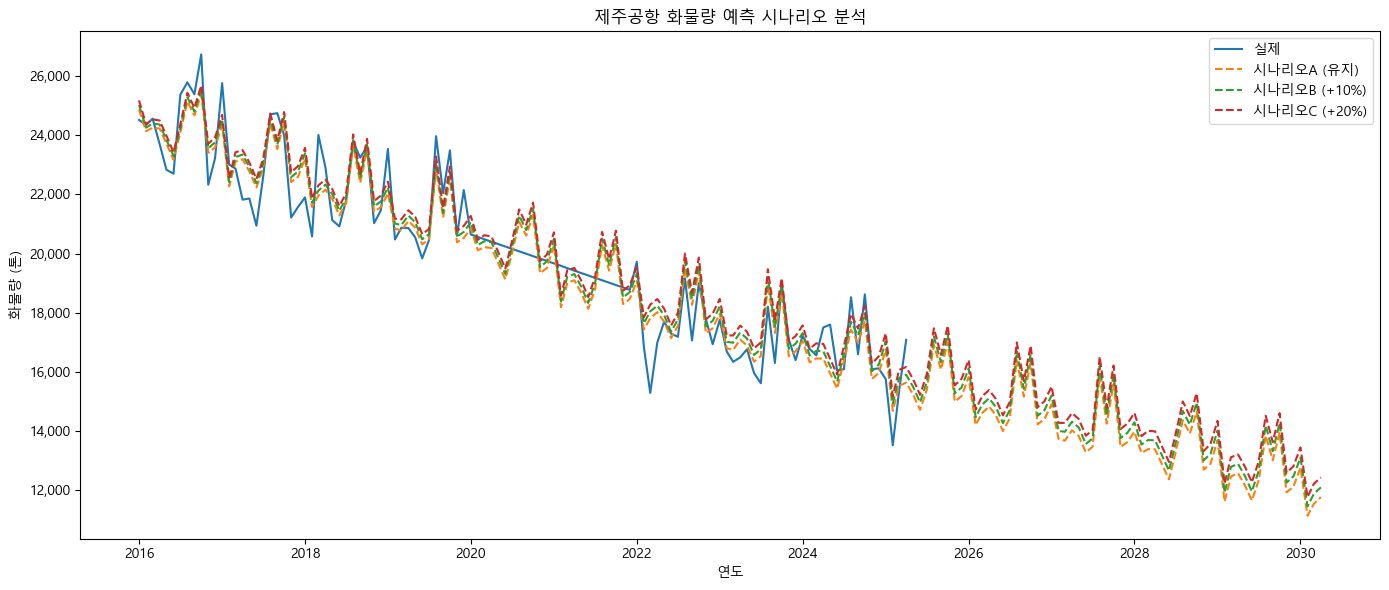

In [ ]:
from prophet import Prophet
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. 데이터 불러오기
file_path = r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\data.xlsx"
df = pd.read_excel(file_path, sheet_name="데이터")
df["Date"] = pd.to_datetime(df[["year", "month"]].assign(DAY=1))
df.set_index("Date", inplace=True)

# 2. 제주공항 이상치 보정
y = df["airport"].astype(float).copy()
outlier_period = (y.index >= "2020-01-01") & (y.index <= "2021-12-31")
X = np.arange(len(y)).reshape(-1, 1)
X_no_outlier = X[~outlier_period]
y_no_outlier = y[~outlier_period]
model_lr = LinearRegression()
model_lr.fit(X_no_outlier, y_no_outlier)
y_pred_outlier = model_lr.predict(X[outlier_period])
y_corrected = y.copy()
y_corrected[outlier_period] = y_pred_outlier

# 3. 제주항 Prophet 모델 학습
port_df = pd.DataFrame({"ds": df.index, "y": df["port"].values})
port_model = Prophet()
port_model.fit(port_df)

# 4. 제주항 미래 예측
future_port = port_model.make_future_dataframe(periods=60, freq="MS")
forecast_port = port_model.predict(future_port)

# 5. 제주항 예측값 DataFrame
port_future_df = forecast_port[["ds", "yhat"]].copy()
port_future_df = port_future_df.rename(columns={"yhat": "exog"})

# 6. 제주공항 학습 데이터
airport_df = pd.DataFrame({"ds": df.index, "y": y_corrected.values})
past_exog = df["port"].reset_index().rename(columns={"Date":"ds","port":"exog"})
train_data = pd.merge(airport_df, past_exog, on="ds")

# 7. Prophet 모델 학습
m = Prophet()
m.add_regressor("exog")
m.fit(train_data)

# 8. 시나리오 데이터 생성
scenario_A = port_future_df.copy()
scenario_B = port_future_df.copy()
scenario_C = port_future_df.copy()

scenario_A["exog"] = scenario_A["exog"]           # baseline
scenario_B["exog"] = scenario_B["exog"] * 1.10    # +10%
scenario_C["exog"] = scenario_C["exog"] * 1.20    # +20%

# 9. 각 시나리오 예측
forecast_A = m.predict(scenario_A)
forecast_B = m.predict(scenario_B)
forecast_C = m.predict(scenario_C)

# 10. 예측 결과 Excel 저장
forecast_A[["ds", "yhat", "yhat_lower", "yhat_upper"]].to_excel(
    r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\제주공항_예측_시나리오A.xlsx", index=False
)
forecast_B[["ds", "yhat", "yhat_lower", "yhat_upper"]].to_excel(
    r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\제주공항_예측_시나리오B.xlsx", index=False
)
forecast_C[["ds", "yhat", "yhat_lower", "yhat_upper"]].to_excel(
    r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\제주공항_예측_시나리오C.xlsx", index=False
)

# 11. 그래프 시각화
plt.figure(figsize=(14,6))
plt.plot(train_data["ds"], train_data["y"], label="실제")

plt.plot(forecast_A["ds"], forecast_A["yhat"], label="시나리오A (유지)", linestyle="--")
plt.plot(forecast_B["ds"], forecast_B["yhat"], label="시나리오B (+10%)", linestyle="--")
plt.plot(forecast_C["ds"], forecast_C["yhat"], label="시나리오C (+20%)", linestyle="--")

plt.title("제주공항 화물량 예측 시나리오 분석")
plt.xlabel("연도")
plt.ylabel("화물량 (톤)")

# Y축 천단위 콤마
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format(int(x), ",")))

plt.legend()
plt.tight_layout()

# 그래프 파일 저장
plt.savefig(r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\제주공항_예측_시나리오분석.png", dpi=300)

plt.show()


In [ ]:
# 2025년 5월 이후 데이터만 필터링
forecast_A_filtered = forecast_A[forecast_A["ds"] >= "2025-05-01"]
forecast_B_filtered = forecast_B[forecast_B["ds"] >= "2025-05-01"]
forecast_C_filtered = forecast_C[forecast_C["ds"] >= "2025-05-01"]

# 출력 확인
print("\n✅ 시나리오 A (baseline)")
print(forecast_A_filtered[["ds", "yhat", "yhat_lower", "yhat_upper"]])

print("\n✅ 시나리오 B (+10%)")
print(forecast_B_filtered[["ds", "yhat", "yhat_lower", "yhat_upper"]])

print("\n✅ 시나리오 C (+20%)")
print(forecast_C_filtered[["ds", "yhat", "yhat_lower", "yhat_upper"]])



✅ 시나리오 A (baseline)
            ds          yhat    yhat_lower    yhat_upper
112 2025-05-01  15240.377706  14226.825081  16332.852159
113 2025-06-01  14719.392536  13691.037470  15794.331543
114 2025-07-01  15401.404665  14441.698491  16490.908736
115 2025-08-01  16915.465178  15860.248911  17994.867570
116 2025-09-01  16077.022835  15041.196058  17134.309824
117 2025-10-01  17009.026260  15919.912600  18036.411936
118 2025-11-01  14996.231730  14014.145057  16043.584927
119 2025-12-01  15186.079946  14097.125551  16182.954642
120 2026-01-01  15827.136451  14772.242728  16889.747557
121 2026-02-01  14207.039072  13294.150926  15182.992319
122 2026-03-01  14606.526122  13613.600155  15671.503404
123 2026-04-01  14832.477345  13796.202193  15908.236828
124 2026-05-01  14534.203851  13564.747602  15589.500435
125 2026-06-01  14001.414167  12923.003652  15028.089952
126 2026-07-01  14434.264861  13429.573467  15475.953308
127 2026-08-01  16400.953843  15285.368456  17474.499751
128 2026-0

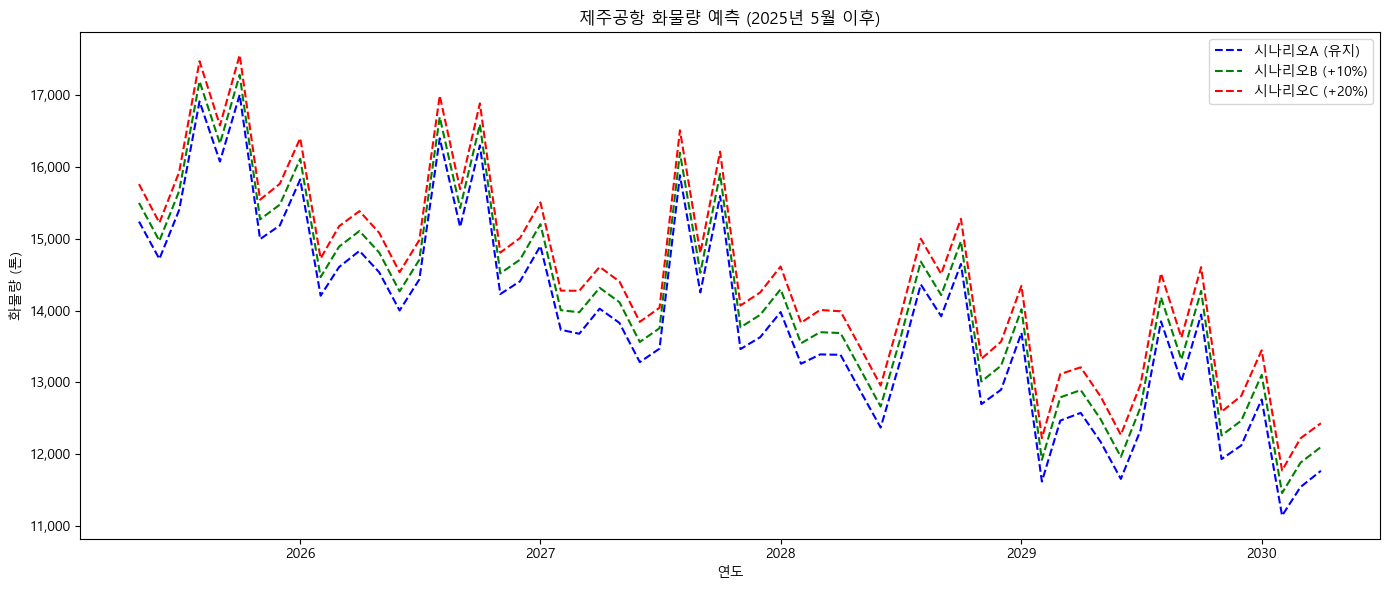

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(14,6))

plt.plot(forecast_A_filtered["ds"], forecast_A_filtered["yhat"], label="시나리오A (유지)", linestyle="--", color="blue")
plt.plot(forecast_B_filtered["ds"], forecast_B_filtered["yhat"], label="시나리오B (+10%)", linestyle="--", color="green")
plt.plot(forecast_C_filtered["ds"], forecast_C_filtered["yhat"], label="시나리오C (+20%)", linestyle="--", color="red")

plt.title("제주공항 화물량 예측 (2025년 5월 이후)")
plt.xlabel("연도")
plt.ylabel("화물량 (톤)")

# Y축 천단위 콤마
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format(int(x), ",")))

plt.legend()
plt.tight_layout()

# 그래프 저장
plt.savefig(r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\제주공항_예측_2025년5월이후.png", dpi=300)

plt.show()


19:47:19 - cmdstanpy - INFO - Chain [1] start processing
19:47:19 - cmdstanpy - INFO - Chain [1] done processing
19:47:19 - cmdstanpy - INFO - Chain [1] start processing
19:47:19 - cmdstanpy - INFO - Chain [1] done processing


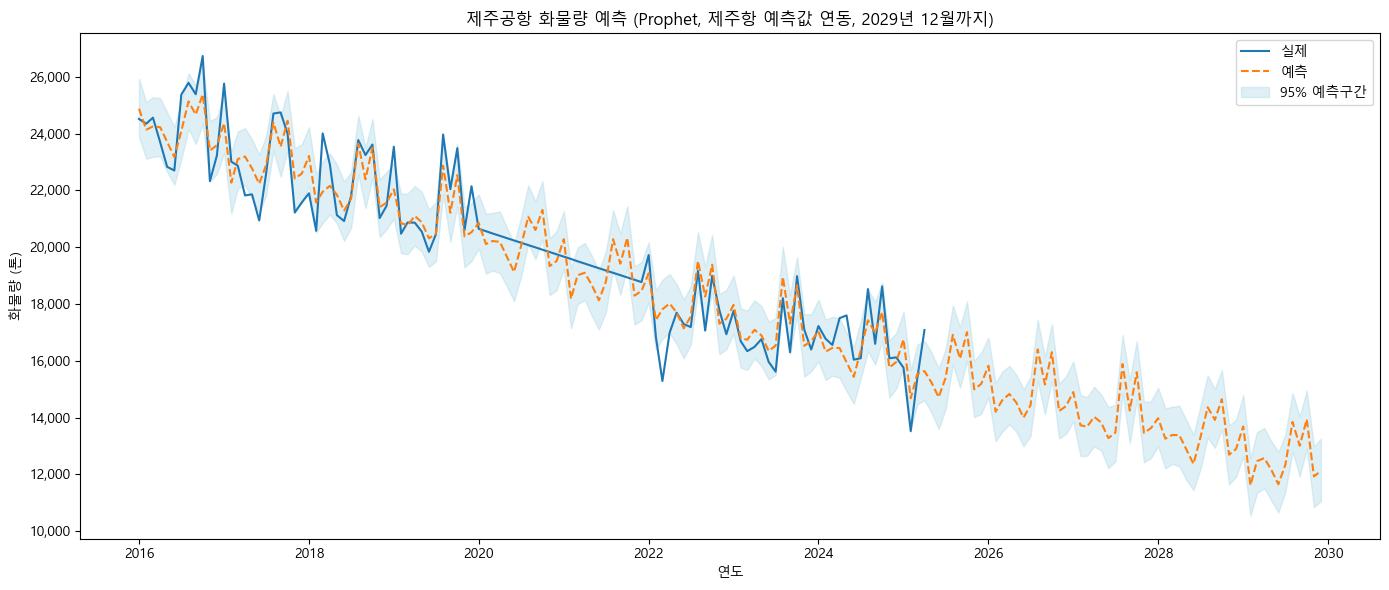

In [ ]:
from prophet import Prophet
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. 데이터 불러오기
file_path = r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\data.xlsx"
df = pd.read_excel(file_path, sheet_name="데이터")
df["Date"] = pd.to_datetime(df[["year", "month"]].assign(DAY=1))
df.set_index("Date", inplace=True)

# 2. 제주공항 이상치 보정
y = df["airport"].astype(float).copy()
outlier_period = (y.index >= "2020-01-01") & (y.index <= "2021-12-31")
X = np.arange(len(y)).reshape(-1, 1)
X_no_outlier = X[~outlier_period]
y_no_outlier = y[~outlier_period]
model_lr = LinearRegression()
model_lr.fit(X_no_outlier, y_no_outlier)
y_pred_outlier = model_lr.predict(X[outlier_period])
y_corrected = y.copy()
y_corrected[outlier_period] = y_pred_outlier

# 3. 제주항 데이터 Prophet 학습
port_df = pd.DataFrame({
    "ds": df.index,
    "y": df["port"].values
})

port_model = Prophet()
port_model.fit(port_df)

# 4. 제주항 미래 데이터 생성 (2029년 12월까지만)
# 마지막 관측월
last_date = port_df["ds"].max()
future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    end="2029-12-01",
    freq="MS"
)

future_port = pd.concat([
    port_df[["ds"]],
    pd.DataFrame({"ds": future_dates})
], ignore_index=True)

forecast_port = port_model.predict(future_port)

# 5. 제주항 예측값 가져오기
future_port_values = forecast_port[["ds", "yhat"]].copy()
future_port_values = future_port_values.rename(columns={"yhat": "exog"})

# 6. 제주공항 데이터 준비
airport_df = pd.DataFrame({
    "ds": df.index,
    "y": y_corrected.values
})

# 7. Prophet 모델 선언 및 외생변수 추가
m = Prophet()
m.add_regressor("exog")

# 8. 과거 데이터 merge
past_exog = df["port"].reset_index().rename(columns={"Date": "ds", "port": "exog"})
train_data = pd.merge(airport_df, past_exog, on="ds")

# 9. 모델 학습
m.fit(train_data)

# 10. 예측용 데이터 준비 (제주항 예측결과 사용)
future_all = future_port_values.copy()

# 11. 제주공항 예측 수행
forecast_airport = m.predict(future_all)

# 12. 결과 저장
result_df = forecast_airport[["ds", "yhat", "yhat_lower", "yhat_upper"]]
result_df.to_excel(r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\제주공항_예측_제주항예측연동.xlsx", index=False)

# 13. 그래프 시각화
plt.figure(figsize=(14,6))
plt.plot(train_data["ds"], train_data["y"], label="실제")
plt.plot(result_df["ds"], result_df["yhat"], label="예측", linestyle="--")
plt.fill_between(
    result_df["ds"],
    result_df["yhat_lower"],
    result_df["yhat_upper"],
    color="lightblue",
    alpha=0.4,
    label="95% 예측구간"
)

plt.title("제주공항 화물량 예측 (Prophet, 제주항 예측값 연동, 2029년 12월까지)")
plt.xlabel("연도")
plt.ylabel("화물량 (톤)")

# Y축 천단위 콤마
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format(int(x), ",")))

plt.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\제주공항_예측_제주항연동그래프.png", dpi=300)
plt.show()


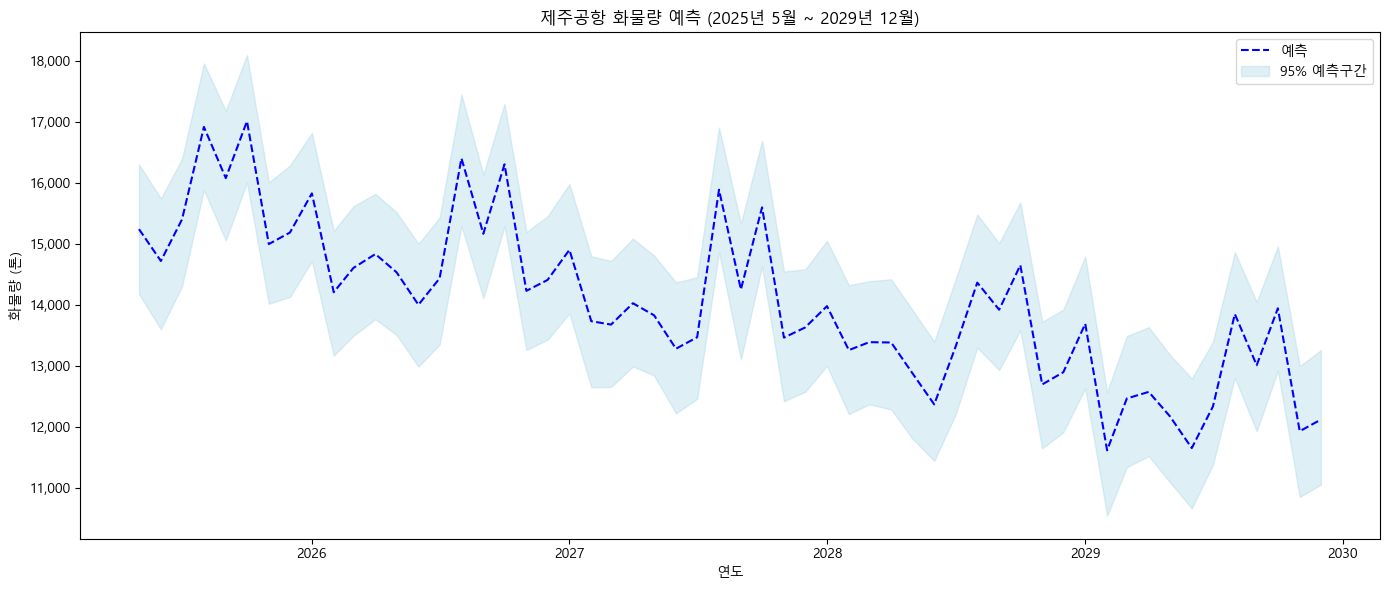

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 2025년 2월 이후만 필터링
result_df_filtered = result_df[
    (result_df["ds"] >= "2025-05-01") &
    (result_df["ds"] <= "2029-12-01")
]

plt.figure(figsize=(14,6))
plt.plot(result_df_filtered["ds"], result_df_filtered["yhat"], label="예측", linestyle="--", color="blue")
plt.fill_between(
    result_df_filtered["ds"],
    result_df_filtered["yhat_lower"],
    result_df_filtered["yhat_upper"],
    color="lightblue",
    alpha=0.4,
    label="95% 예측구간"
)

plt.title("제주공항 화물량 예측 (2025년 5월 ~ 2029년 12월)")
plt.xlabel("연도")
plt.ylabel("화물량 (톤)")

# Y축 천단위 콤마
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format(int(x), ",")))

plt.legend()
plt.tight_layout()

# 그래프 저장
plt.savefig(r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\제주공항_예측_2025년2월부터.png", dpi=300)

plt.show()


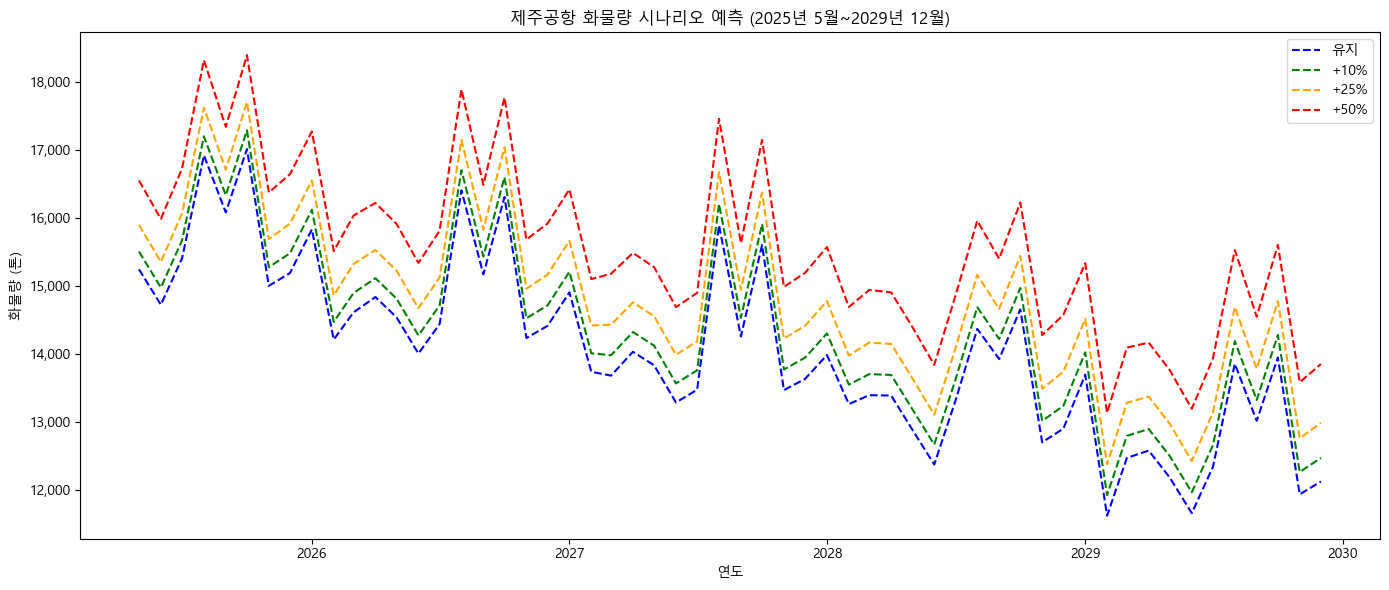

In [ ]:
# 🚀 10. 예측용 데이터 준비 (제주항 예측결과 사용)
future_all_base = future_port_values.copy()

# 🚀 11. 시나리오 데이터 생성
scenario_baseline = future_all_base.copy()
scenario_plus10 = future_all_base.copy()
scenario_plus25 = future_all_base.copy()
scenario_plus50 = future_all_base.copy()

scenario_baseline["exog"] = scenario_baseline["exog"]                # baseline
scenario_plus10["exog"] = scenario_plus10["exog"] * 1.10             # +10%
scenario_plus25["exog"] = scenario_plus25["exog"] * 1.25             # +25%
scenario_plus50["exog"] = scenario_plus50["exog"] * 1.50             # +50%

# 🚀 12. 각 시나리오 예측
forecast_baseline = m.predict(scenario_baseline)
forecast_plus10 = m.predict(scenario_plus10)
forecast_plus25 = m.predict(scenario_plus25)
forecast_plus50 = m.predict(scenario_plus50)

# 🚀 13. 결과 Excel 저장
forecast_baseline[["ds", "yhat", "yhat_lower", "yhat_upper"]].to_excel(
    r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\제주공항_예측_시나리오_baseline.xlsx", index=False
)
forecast_plus10[["ds", "yhat", "yhat_lower", "yhat_upper"]].to_excel(
    r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\제주공항_예측_시나리오_plus10.xlsx", index=False
)
forecast_plus25[["ds", "yhat", "yhat_lower", "yhat_upper"]].to_excel(
    r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\제주공항_예측_시나리오_plus25.xlsx", index=False
)
forecast_plus50[["ds", "yhat", "yhat_lower", "yhat_upper"]].to_excel(
    r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\제주공항_예측_시나리오_plus50.xlsx", index=False
)

# 🚀 14. 그래프 시각화 (2025년 2월 이후만)
result_baseline = forecast_baseline[forecast_baseline["ds"] >= "2025-05-01"]
result_plus10 = forecast_plus10[forecast_plus10["ds"] >= "2025-05-01"]
result_plus25 = forecast_plus25[forecast_plus25["ds"] >= "2025-05-01"]
result_plus50 = forecast_plus50[forecast_plus50["ds"] >= "2025-05-01"]

plt.figure(figsize=(14,6))

plt.plot(result_baseline["ds"], result_baseline["yhat"], label="유지", linestyle="--", color="blue")
plt.plot(result_plus10["ds"], result_plus10["yhat"], label="+10%", linestyle="--", color="green")
plt.plot(result_plus25["ds"], result_plus25["yhat"], label="+25%", linestyle="--", color="orange")
plt.plot(result_plus50["ds"], result_plus50["yhat"], label="+50%", linestyle="--", color="red")

plt.title("제주공항 화물량 시나리오 예측 (2025년 5월~2029년 12월)")
plt.xlabel("연도")
plt.ylabel("화물량 (톤)")

# Y축 천단위 콤마
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: format(int(x), ",")))

plt.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\DAEJIN\Desktop\무역학회지 8월호\제주공항_예측_시나리오그래프.png", dpi=300)
plt.show()
